# 13. From Pairs to People

**The question.** A similarity is not a probability, and pairs are not people. The encoder
hands back cosines; the operating-point protocol (PLAN §5) needs *match probabilities* it
can threshold at declared precision and cost points — that is **calibration** (CAL-01). And
accepted pairs are still not entities: some clustering scheme must turn the pair graph into
a partition, and notebook 07 showed the naive scheme's folklore catastrophe failing to
materialize *because the matchkey/FS candidate graph was too starved to percolate* —
explicitly leaving open what happens on a dense candidate graph — that is **clustering**
(CLU-01). This notebook measures what each step actually buys: how far a raw cosine is from
a probability (and whether the fix survives name-frequency stratification), and how much the
choice of clustering scheme moves entity-level metrics once scores are calibrated and the
threshold is set by protocol rather than by each scheme's sweet spot.

**What this notebook settles.** (1) **CAL-01**: the NB12-recipe encoder is retrained
identically (recipe read from `bas02_blocking_frontier` meta, budget stated); labeled
TRAIN-half pairs (matchkey candidates + dense top-k candidates + uniform sampled negatives)
are scored, and isotonic + Platt calibration maps are fitted globally and per
family-name-frequency stratum, with out-of-sample reliability curves, ECE per fit×stratum,
and the per-stratum threshold-for-0.99-precision table — the common-name discount made
visible. Everything lands in `cal01_calibration_map`. (2) **CLU-01**: on the EVAL half's
calibrated dense-candidate scores, transitive closure vs capped agglomerative vs star
clustering vs greedy correlation at the protocol operating points (fixed precision
{0.99, 0.995} + the cost grid, loud fallbacks), each with entity-BCa CIs; plus a
threshold-sweep percolation view whose shape is compared to NB07's FS sweep
(`chain_merge_demo`), with an Erdős–Rényi mean-degree onset heuristic. Everything lands in
`clu01_clustering_scores`. The `# [RUN-IN-TARGET node]` placard prices the definitive 1e7
hub-resistance run from THIS run's measured coefficients.

**Scope honesty, up front.** One trained encoder, one seed, one corpus draw: every verdict
below says "demonstration" and quotes the MET-04 replicate bar as the caution. No entity
appears on both sides of any train/eval boundary (`met07_splits` entity-disjoint scheme,
PLAN §5), and the calibration fit/eval split is itself entity-disjoint *within* the train
half. The corpus is `historical_50k`-derived (public Wikidata historical figures,
error-injected); NC data enters only as the aggregate channel rates in the corpus meta —
**no NC person-level value appears anywhere in this notebook, so there is nothing to mask**
(DATA_GOVERNANCE.md).

In [1]:
import re
import time

import numpy as np
import pandas as pd
from IPython.display import display
from mpl_toolkits.axes_grid1 import make_axes_locatable

from er_lab.blocking import ann, matchkeys
from er_lab.cluster.schemes import (
    capped_agglomerative,
    greedy_correlation,
    star_clustering,
    transitive_closure,
)
from er_lab.config import config_hash, load_config_from_env, set_all_seeds
from er_lab.data.schema import NON_TEXT_ROLES, ROLES
from er_lab.eval.bootstrap import bootstrap_ci, paired_delta
from er_lab.eval.metrics import bcubed, blocking_metrics, pairwise
from er_lab.eval.operating_points import cost_optimal_threshold, find_threshold_for_precision
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.score.calibrate import fit_calibrator
from er_lab.serialize import serialize_frame
from er_lab.train.loop import train_encoder

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

The encoder shape and step budget are the same tier table as notebooks 09/12, so the NB12
recipe transfers verbatim (and is asserted against the registered recipe below, not
assumed). The candidate budget k=10 is `bas02_blocking_frontier`'s noise-slice budget —
CLU-01 clusters the graph BAS-02 measured, at the same matched budget. Protocol constants
(precision targets, cost grid) are PLAN §5, identical at every tier; analysis budgets
(grid, bootstrap replicates, sweep resolution, calibration bins) scale with tier. Smoke
budget for the whole notebook: **<= ~30 min uncontended on the 4-CPU container** (a
concurrent workload can inflate wall-clock 2–4x; per-section timings print at the end).

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}  # train records
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
ENC_BATCH = 256  # inference encode batch
K_CAND = 10  # dense candidate budget (bas02's noise-slice k; matched, not tuned here)
GRID = {"smoke": 80, "mid": 150, "target": 200, "analytical": 80}[TIER]
N_BOOT = {"smoke": 500, "mid": 1000, "target": 2000, "analytical": 500}[TIER]
SWEEP_N = {"smoke": 16, "mid": 24, "target": 36, "analytical": 16}[TIER]
# protocol constants (PLAN §5 — identical at every tier, never tuned):
PREC_TARGETS = (0.99, 0.995)  # fixed B-cubed entity-precision operating points
COST_GRID = ((1, 1), (10, 1), (100, 1))  # (fp_cost, fn_cost) — FP:FN 1:1 / 10:1 / 100:1
PAIR_PREC_TARGET = 0.99  # CAL-01's per-stratum pairwise-precision threshold table
CAL_BINS = 10  # equal-width reliability/ECE bins on [0, 1]
CAL_FIT_SHARE = 0.7  # entity share of the train half used to FIT calibrators
MAP_GRID = np.round(np.linspace(-1.0, 1.0, 81), 4)  # cosine grid for the registered maps
ANCHOR_THRESHOLDS = (0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                     0.9, 0.95, 0.99, 0.995, 0.999)
PRIMARY_SEED = int(cfg.run.seed)

cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
print(f"tier={TIER}: encoder {MODEL_SHAPE}, steps={STEPS}, batch={BATCH}, "
      f"train-slice budget {SIZES[TIER]}; dense candidate k={K_CAND}; grid={GRID}, "
      f"n_boot={N_BOOT}, sweep={len(ANCHOR_THRESHOLDS)} anchors + {SWEEP_N} quantiles; "
      f"protocol: precision {PREC_TARGETS}, cost {COST_GRID}, "
      f"pair-precision table target {PAIR_PREC_TARGET}, {CAL_BINS} ECE bins")

tier=smoke: encoder {'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}, steps=250, batch=64, train-slice budget 3000; dense candidate k=10; grid=80, n_boot=500, sweep=16 anchors + 16 quantiles; protocol: precision (0.99, 0.995), cost ((1, 1), (10, 1), (100, 1)), pair-precision table target 0.99, 10 ECE bins


## 1. The arena: one corpus, one recipe, one discipline

Everything loads through the registry at this run's tier. `bas02_blocking_frontier` (the
DAG-declared upstream) supplies the **encoder recipe** this notebook retrains — loss,
regime, miner, budget, field set, serialization, all read from its meta, not re-chosen —
plus the measured dense-blocking coefficients the placard scales. `chain_merge_demo` is
NB07's registered FS-sweep, loaded for the percolation-shape comparison its closing notes
promised this notebook. `met07_splits` (produced by notebook 05 alongside
`calibrated_corpus`, so guaranteed present whenever the declared requirement is — loaded
with the same hard-fail placard semantics) enforces the eval discipline. `met04_power_table`
supplies the replicate bar every single-seed verdict is read through.

`TEXT_ROLES` inherits notebook 08's **measured decision**: `full_name` is EXCLUDED — it is
a verbatim join of the name parts that roughly doubles serialized length (forcing truncation
at the smoke byte window) and notebook 05 leaves it stale under nickname/typo edits, so
keeping it would leak the clean name past the injected noise.

In [4]:
t_sec = time.time()
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
bas02, bas02_meta = registry.load("bas02_blocking_frontier", tier=cfg.run.tier)
splits, _splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
cm_demo, cm_meta = registry.load("chain_merge_demo", tier=cfg.run.tier)
met04, met04_meta = registry.load("met04_power_table", tier=cfg.run.tier)

CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
BAS02_PROVENANCE = (
    f"bas02_blocking_frontier run {bas02_meta['created_at']} "
    f"(cfg {bas02_meta['config_hash']}, tier {bas02_meta['tier']})"
)
RECIPE = dict(bas02_meta["extra"]["encoder_recipe"])
CAP = int(corpus_meta["extra"]["dup_dist"]["max"])
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities; "
      f"source={corpus['source'].unique().tolist()} (public historical records; NC enters "
      "only as aggregate channel rates in the corpus meta — nothing to mask)")
print(f"recipe source: {BAS02_PROVENANCE}")
print(f"  NB12 recipe: loss={RECIPE['loss']}, regime={RECIPE['regime']}, "
      f"miner={RECIPE['miner']}, augment={RECIPE['augment']}, steps={RECIPE['steps']} x "
      f"batch {RECIPE['batch']}, model={RECIPE['model']} ({RECIPE['n_params']:,} params; "
      f"NB12 measured {RECIPE['train_secs']:.0f}s train)")
print(f"cluster-size prior (corpus meta dup_dist): max {CAP} records per base-record cluster "
      "— capped_agglomerative's cap, same source as NB07")

# the recipe must be THIS tier's budget table, or retraining 'identically' would be a lie
if str(bas02_meta["tier"]) == TIER:
    assert int(RECIPE["steps"]) == STEPS and int(RECIPE["batch"]) == BATCH, (
        f"recipe budget {RECIPE['steps']}x{RECIPE['batch']} != tier table {STEPS}x{BATCH}"
    )
    assert dict(RECIPE["model"]) == MODEL_SHAPE, (
        f"recipe shape {RECIPE['model']} != tier table {MODEL_SHAPE}"
    )
cfg.model.kind = "scratch_char" if RECIPE["regime"] == "scratch_char" else "pretrained"

corpus: calibrated_corpus run 2026-08-29T15:42:13.364770+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities; source=['historical_50k'] (public historical records; NC enters only as aggregate channel rates in the corpus meta — nothing to mask)
recipe source: bas02_blocking_frontier run 2026-08-29T16:13:38.288064+00:00 (cfg 98af614e2bcd, tier smoke)
  NB12 recipe: loss=infonce, regime=scratch_char, miner=inbatch, augment=none, steps=250 x batch 64, model={'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128} (330,880 params; NB12 measured 35s train)
cluster-size prior (corpus meta dup_dist): max 20 records per base-record cluster — capped_agglomerative's cap, same source as NB07


In [5]:
# NB08's measured field-set decision, inherited (see the section note above).
TEXT_ROLES = ["given_name", "family_name", "dob", "city", "zip", "sex"]
assert TEXT_ROLES == list(RECIPE["text_roles"]), (
    f"TEXT_ROLES {TEXT_ROLES} != the registered recipe's {RECIPE['text_roles']}"
)
KEEP_COLS = ["record_id", "entity_id"] + TEXT_ROLES
_loop_roles = [c for c in KEEP_COLS if c in ROLES and c not in NON_TEXT_ROLES]
assert _loop_roles == TEXT_ROLES, (
    f"training-loop role rule would diverge from TEXT_ROLES on KEEP_COLS: {_loop_roles}"
)
print(f"TEXT_ROLES (full_name excluded, NB08 decision) = {TEXT_ROLES}")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"
arena = corpus.reset_index(drop=True)
N_ARENA = len(arena)
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
TRUTH_ALL = arena.set_index(arena["record_id"].astype(str))["entity_id"]
print(f"split {SCHEME}: {len(train_full):,} train / {len(eval_full):,} eval records "
      f"({train_full['entity_id'].nunique():,} / {eval_full['entity_id'].nunique():,} "
      "entities, 0 straddling). CAL-01 fits on TRAIN-half pairs only; CLU-01 clusters the "
      "EVAL half only — no entity crosses the boundary.")

SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)
assert {"scheme": SER_SCHEME, "missing": SER_MISSING} == dict(RECIPE["serialization"]), (
    "serialization drifted from the registered recipe"
)
ARENA_TEXTS = serialize_frame(
    arena, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
).tolist()
ARENA_POS = pd.Series(np.arange(N_ARENA), index=arena["record_id"].astype(str))
print(f"serialization: scheme={SER_SCHEME} missing={SER_MISSING} (recipe-locked)")

TEXT_ROLES (full_name excluded, NB08 decision) = ['given_name', 'family_name', 'dob', 'city', 'zip', 'sex']


split entity_disjoint: 16,164 train / 16,095 eval records (1,252 / 1,255 entities, 0 straddling). CAL-01 fits on TRAIN-half pairs only; CLU-01 clusters the EVAL half only — no entity crosses the boundary.


serialization: scheme=colval missing=token (recipe-locked)


In [6]:
# The MET-04 caution bar for everything downstream of ONE trained encoder (same read as
# notebook 12: residual-inclusive from the meta when present, else computed and said so).
SD_REPLICATE = float(met04_meta["extra"]["sd_replicate"])
_comps = met04[met04["kind"] == "variance_component"].set_index("component")["variance"]
if "detect_bar_residual_inclusive" in met04_meta["extra"]:
    BAR_FULL = float(met04_meta["extra"]["detect_bar_residual_inclusive"])
    BAR_SRC = "read from met04_power_table meta"
else:
    BAR_FULL = float(2.0 * np.sqrt(2.0) * np.sqrt(_comps.sum()))
    BAR_SRC = ("computed here as 2*sqrt(2)*sqrt(seed+noise_draw+residual) — the registered "
               "meta carries only the residual-EXCLUSIVE sd_replicate")
print(f"MET-04 bars (B3F1 units; table scope: {met04['scope'].iloc[0]}): "
      f"sd_replicate={SD_REPLICATE:.4f}, residual-inclusive single-seed bar "
      f"{BAR_FULL:.4f} ({BAR_SRC}). This bar is CLU-01's pre-registered yardstick for "
      "'does scheme choice matter more than replicate noise'.")
tick("§1 arena + recipe + bars", t_sec)

MET-04 bars (B3F1 units; table scope: smoke_pilot): sd_replicate=0.0305, residual-inclusive single-seed bar 0.0865 (read from met04_power_table meta). This bar is CLU-01's pre-registered yardstick for 'does scheme choice matter more than replicate noise'.
[section timing] §1 arena + recipe + bars: 0s


## 2. CAL-01, the conjecture — registered before the encoder trains

The card is registered now: before the encoder retrains, before a single pair is scored.
The decision rule lives inside the prediction; the verdict at the end of section 5 scores
exactly it.

In [7]:
_ = conjecture_card(
    card_id="CAL-01",
    conjecture=(
        "A cosine is not a probability: read naively as one, the trained encoder's raw "
        "similarity is badly miscalibrated on held-out pairs; isotonic regression fixes the "
        "global score->probability map, but per name-frequency strata the residual "
        "heterogeneity survives — the same cosine means less between common family names "
        "than between rare ones, so common names need a higher threshold for the same "
        "precision (the common-name discount)."
    ),
    pressure=(
        "calibration method {none (naive (cos+1)/2 rescale), isotonic, Platt} x scope "
        "{global, per family-name-frequency stratum} fitted on labeled TRAIN-half pairs "
        "(matchkey candidates + dense ANN top-10 candidates + uniform sampled negatives, "
        "labeled by truth) scored by the NB12-recipe encoder retrained identically (recipe "
        "read from bas02_blocking_frontier meta; identical seed, train slice, and step "
        "budget, stated in-notebook); strata are corpus-frequency terciles of the commoner "
        "member's family name (rare/mid/common) plus a 'missing' stratum when either "
        "member's family name is blank"
    ),
    property=(
        "reliability — the score->empirical-match-rate map, measured OUT-OF-SAMPLE on pairs "
        "of held-out calibration-eval entities (an entity-disjoint fit/eval split within "
        "the train half), summarized as expected calibration error (ECE, 10 equal-width "
        "bins on [0,1]) per fit and per stratum, plus the per-stratum raw-cosine threshold "
        "attaining pairwise precision 0.99"
    ),
    metric=(
        "the ECE table (fit x stratum) and the per-stratum threshold-for-0.99-pairwise-"
        "precision table, both on held-out pairs, registered in cal01_calibration_map "
        "(reliability-bin rows + ECE rows + score-grid map rows + threshold rows); "
        "downstream, the calibrated probabilities CLU-01 clusters on"
    ),
    prediction=(
        "P1: raw cosine read as (cos+1)/2 has held-out ECE >= 0.10 while the global "
        "isotonic map's held-out ECE is <= 0.03 (all-pairs stratum). P2 (subordinate, "
        "cannot flip the outcome): under the GLOBAL isotonic map the common tercile's "
        "held-out ECE exceeds the per-stratum isotonic fit's common-tercile ECE — residual "
        "heterogeneity a single global map cannot remove. P3: the raw-cosine threshold "
        "attaining pairwise precision 0.99 is strictly higher for the common tercile than "
        "for the rare tercile; if either stratum cannot attain 0.99 (PLAN §5 "
        "highest-attainable fallback, flagged loudly), P3 is read at the highest precision "
        "attainable in BOTH strata. Decision rule, pre-registered: CONFIRMED iff P1 and P3 "
        "both hold; REFUTED iff raw ECE < 0.03 (nothing to fix) or the common-tercile "
        "threshold at the P3 comparison point is <= the rare-tercile threshold; "
        "UNEXPLAINED otherwise. One encoder, one seed, one corpus draw: whatever the "
        "outcome, this is a demonstration — CAL-01's definitive home is the mid tier "
        "(PLAN §3)."
    ),
    registry=registry,
)

### Conjecture card `CAL-01`

| | |
|---|---|
| **Conjecture** | A cosine is not a probability: read naively as one, the trained encoder's raw similarity is badly miscalibrated on held-out pairs; isotonic regression fixes the global score->probability map, but per name-frequency strata the residual heterogeneity survives — the same cosine means less between common family names than between rare ones, so common names need a higher threshold for the same precision (the common-name discount). |
| **Pressure (dial)** | calibration method {none (naive (cos+1)/2 rescale), isotonic, Platt} x scope {global, per family-name-frequency stratum} fitted on labeled TRAIN-half pairs (matchkey candidates + dense ANN top-10 candidates + uniform sampled negatives, labeled by truth) scored by the NB12-recipe encoder retrained identically (recipe read from bas02_blocking_frontier meta; identical seed, train slice, and step budget, stated in-notebook); strata are corpus-frequency terciles of the commoner member's family name (rare/mid/common) plus a 'missing' stratum when either member's family name is blank |
| **Embedding property** | reliability — the score->empirical-match-rate map, measured OUT-OF-SAMPLE on pairs of held-out calibration-eval entities (an entity-disjoint fit/eval split within the train half), summarized as expected calibration error (ECE, 10 equal-width bins on [0,1]) per fit and per stratum, plus the per-stratum raw-cosine threshold attaining pairwise precision 0.99 |
| **System metric** | the ECE table (fit x stratum) and the per-stratum threshold-for-0.99-pairwise-precision table, both on held-out pairs, registered in cal01_calibration_map (reliability-bin rows + ECE rows + score-grid map rows + threshold rows); downstream, the calibrated probabilities CLU-01 clusters on |
| **Pre-registered prediction** | P1: raw cosine read as (cos+1)/2 has held-out ECE >= 0.10 while the global isotonic map's held-out ECE is <= 0.03 (all-pairs stratum). P2 (subordinate, cannot flip the outcome): under the GLOBAL isotonic map the common tercile's held-out ECE exceeds the per-stratum isotonic fit's common-tercile ECE — residual heterogeneity a single global map cannot remove. P3: the raw-cosine threshold attaining pairwise precision 0.99 is strictly higher for the common tercile than for the rare tercile; if either stratum cannot attain 0.99 (PLAN §5 highest-attainable fallback, flagged loudly), P3 is read at the highest precision attainable in BOTH strata. Decision rule, pre-registered: CONFIRMED iff P1 and P3 both hold; REFUTED iff raw ECE < 0.03 (nothing to fix) or the common-tercile threshold at the P3 comparison point is <= the rare-tercile threshold; UNEXPLAINED otherwise. One encoder, one seed, one corpus draw: whatever the outcome, this is a demonstration — CAL-01's definitive home is the mid tier (PLAN §3). |

*Immutable — sha256 `c9a51dfae14d`; registered before the affected runs, never edited (PLAN §5).*


## 3. The encoder, retrained to the registered recipe — budget stated

Identical to notebook 12 by construction: the same entity-complete train slice (same
subsample seed), the same recipe read from the registry, the same seed into
`train.loop.train_encoder` — deterministic under seed, so this *is* the NB12 encoder,
re-derived rather than re-invented (weights are not registered artifacts; the recipe +
seed are the reproducible object). The budget is the recipe's exact optimizer-step count
at the recipe's batch size — asserted from the training history, wall-clock measured.

In [8]:
def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same notebook-local helper as notebooks 05/09/12 — a shared home in er_lab.data
    would serve; reported as a package gap.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


t_sec = time.time()
train_slice = entity_complete_subsample(
    train_full, SIZES[TIER], np.random.default_rng(PRIMARY_SEED)
)[KEEP_COLS]
assert len(train_slice) == int(RECIPE["train_slice"]["records"]) or str(
    bas02_meta["tier"]
) != TIER, "train slice diverged from the registered recipe's — not an identical retrain"
print(f"train slice: {len(train_slice):,} records / {train_slice['entity_id'].nunique():,} "
      f"entities (entity-complete, same construction+seed as NB12)")

set_all_seeds(PRIMARY_SEED)
encoder = build_encoder(cfg)
N_PARAMS = int(sum(p.numel() for p in encoder.parameters()))
_t0 = time.time()
encoder, hist = train_encoder(
    encoder, train_slice, cfg, loss_name=str(RECIPE["loss"]), miner_name=str(RECIPE["miner"]),
    augment_kind=str(RECIPE["augment"]), steps=STEPS, seed=PRIMARY_SEED,
)
TRAIN_SECS = time.time() - _t0
assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
    f"budget violation: expected exactly {STEPS} optimizer steps, history shows {len(hist)}"
)
print(f"trained: {RECIPE['loss']}/{RECIPE['miner']}/{RECIPE['augment']}, {STEPS} steps x "
      f"batch {BATCH} (asserted from history), {N_PARAMS:,} params -> {TRAIN_SECS:.0f}s "
      f"(NB12 measured {RECIPE['train_secs']:.0f}s for the same budget); "
      f"final train loss {float(hist['loss'].tail(20).mean()):.4f}")
tick("§3a recipe retrain", t_sec)

train slice: 3,010 records / 222 entities (entity-complete, same construction+seed as NB12)


trained: infonce/inbatch/none, 250 steps x batch 64 (asserted from history), 330,880 params -> 36s (NB12 measured 35s for the same budget); final train loss 1.0417
[section timing] §3a recipe retrain: 36s


In [9]:
t_sec = time.time()
_t0 = time.time()
EMB = encoder.encode(ARENA_TEXTS, batch_size=ENC_BATCH)
ENCODE_SECS = time.time() - _t0
ENC_RATE = N_ARENA / ENCODE_SECS
print(f"encoded {N_ARENA:,} records -> ({EMB.shape[0]:,}, {EMB.shape[1]}) in "
      f"{ENCODE_SECS:.0f}s = {ENC_RATE:,.0f} rec/s on this container (rows L2-normalized, "
      "so a pair's dot product IS its cosine)")
tick("§3b encode", t_sec)

encoded 32,259 records -> (32,259, 128) in 19s = 1,741 rec/s on this container (rows L2-normalized, so a pair's dot product IS its cosine)
[section timing] §3b encode: 19s


In [10]:
def pair_cosines(a_ids: pd.Series, b_ids: pd.Series) -> np.ndarray:
    """Cosine per pair from the arena embedding matrix (positional lookup)."""
    ia = ARENA_POS.loc[a_ids.astype(str)].to_numpy()
    ib = ARENA_POS.loc[b_ids.astype(str)].to_numpy()
    return np.einsum("ij,ij->i", EMB[ia], EMB[ib]).astype(float)

## 4. The labeled pairs CAL-01 fits on — and the strata

**The fit distribution is the deployed distribution.** The calibrate module's own caveat
(selection bias) says: fit on pairs drawn the way the deployed scorer sees them —
post-blocking. So the TRAIN-half fit set is the union of (a) **matchkey candidates** (the
deterministic blocking arm), (b) **dense ANN top-k candidates** (`K_CAND`) over the
trained embeddings — exactly the candidate distribution CLU-01 clusters, hard negatives
included — and (c) **uniform sampled negatives**, which anchor the score range dense
blocking never proposes (calibration must also be right about pairs that are obviously
different people). Every pair is labeled by truth. The stratum instrument: corpus-wide
family-name frequency (case/whitespace-normalized for counting only — values themselves
are never cleaned, PRS-01 owns standardization), record-level terciles over non-missing
names; a pair's stratum is the band of its **commoner** member (the commoner name
dominates collision risk), with a 'missing' stratum when either side is blank.

The calibration fit/eval split is **entity-disjoint within the train half**
(`CAL_FIT_SHARE` of train entities fit, the rest evaluate): isotonic can memorize its fit
set into near-zero in-sample ECE, so every reliability number this notebook reports is
out-of-sample.

In [11]:
t_sec = time.time()
FAM_NORM = corpus["family_name"].astype("string").str.strip().str.upper()
FAM_FREQ = FAM_NORM.value_counts()  # record-level frequency, whole corpus (deployment stat)
_rec_freq = FAM_NORM.map(FAM_FREQ).astype("Float64").to_numpy(dtype=float, na_value=np.nan)
TERCILE_EDGES = tuple(float(q) for q in np.nanquantile(_rec_freq, [1 / 3, 2 / 3]))
FREQ_OF = pd.Series(_rec_freq, index=arena["record_id"].astype(str))
print(f"family-name frequency instrument: {FAM_FREQ.size:,} distinct names over "
      f"{int(FAM_NORM.notna().sum()):,} named records ({float(FAM_NORM.isna().mean()):.1%} "
      f"missing); record-level tercile edges at {TERCILE_EDGES[0]:.0f} and "
      f"{TERCILE_EDGES[1]:.0f} occurrences (top names: "
      + ", ".join(f"{n} x{c}" for n, c in FAM_FREQ.head(3).items()) + ")")


def pair_strata(a_ids: pd.Series, b_ids: pd.Series) -> np.ndarray:
    """Stratum per pair: tercile band of the commoner member's family name, or 'missing'."""
    fa = FREQ_OF.loc[a_ids.astype(str)].to_numpy()
    fb = FREQ_OF.loc[b_ids.astype(str)].to_numpy()
    hi = np.fmax(fa, fb)  # fmax ignores one-sided NaN; NaN only if both are NaN
    out = np.where(
        hi <= TERCILE_EDGES[0], "rare", np.where(hi <= TERCILE_EDGES[1], "mid", "common")
    ).astype(object)
    out[np.isnan(fa) | np.isnan(fb)] = "missing"
    return out

family-name frequency instrument: 2,662 distinct names over 29,387 named records (8.9% missing); record-level tercile edges at 16 and 31 occurrences (top names: BARONET x442, SMITH x168, CHAPMAN x122)


In [12]:
# The three pair sources on the train half, unioned and deduplicated (first source kept).
mk_cand = matchkeys.candidates(train_full, passes=matchkeys.default_passes(train_full))
tr_pos = ARENA_POS.loc[train_full["record_id"].astype(str)].to_numpy()
ann_cand = ann.candidates(train_full, EMB[tr_pos], k=K_CAND, index="flat")

_rng_neg = np.random.default_rng(PRIMARY_SEED + 7)
_n_neg = len(mk_cand) + len(ann_cand)
_tr_ids = train_full["record_id"].astype(str).to_numpy()
_ia = _rng_neg.integers(0, len(_tr_ids), size=int(1.2 * _n_neg))
_ib = _rng_neg.integers(0, len(_tr_ids), size=int(1.2 * _n_neg))
_keep = _ia != _ib
rand_pairs = pd.DataFrame({
    "a": np.minimum(_tr_ids[_ia[_keep]], _tr_ids[_ib[_keep]]),
    "b": np.maximum(_tr_ids[_ia[_keep]], _tr_ids[_ib[_keep]]),
}).drop_duplicates().head(_n_neg)

fitpairs = pd.concat(
    [mk_cand.assign(source="matchkeys"), ann_cand.assign(source=f"ann_flat_k{K_CAND}"),
     rand_pairs.assign(source="uniform_random")],
    ignore_index=True,
)
fitpairs["a"], fitpairs["b"] = fitpairs["a"].astype(str), fitpairs["b"].astype(str)
fitpairs = fitpairs.drop_duplicates(subset=["a", "b"], keep="first").reset_index(drop=True)
fitpairs["label"] = (
    TRUTH_ALL.loc[fitpairs["a"]].to_numpy() == TRUTH_ALL.loc[fitpairs["b"]].to_numpy()
).astype(float)
fitpairs["cos"] = pair_cosines(fitpairs["a"], fitpairs["b"])
fitpairs["stratum"] = pair_strata(fitpairs["a"], fitpairs["b"])

_tr_ents = pd.Index(train_full["entity_id"].unique())
_rng_split = np.random.default_rng(PRIMARY_SEED + 13)
_fit_ents = set(_tr_ents[_rng_split.permutation(len(_tr_ents))[: int(CAL_FIT_SHARE
                                                                     * len(_tr_ents))]])
_ea = TRUTH_ALL.loc[fitpairs["a"]].to_numpy()
_eb = TRUTH_ALL.loc[fitpairs["b"]].to_numpy()
_in_fit = np.isin(_ea, list(_fit_ents)) & np.isin(_eb, list(_fit_ents))
_in_ev = ~np.isin(_ea, list(_fit_ents)) & ~np.isin(_eb, list(_fit_ents))
calfit = fitpairs[_in_fit].reset_index(drop=True)
caleval = fitpairs[_in_ev].reset_index(drop=True)
SEEN_SHARE = float(np.isin(_ea, train_slice["entity_id"].unique()).mean())

print(f"train-half labeled pairs: {len(fitpairs):,} "
      f"({dict(fitpairs['source'].value_counts())}); positive rate "
      f"{fitpairs['label'].mean():.3f}")
print(f"  strata: {dict(fitpairs['stratum'].value_counts())}")
print(f"  calibration split (entity-disjoint within train): {len(calfit):,} fit pairs "
      f"({len(_fit_ents):,} entities) / {len(caleval):,} held-out eval pairs; "
      f"{_in_fit.mean():.0%} fit, {_in_ev.mean():.0%} eval, rest straddle (dropped)")
print(f"  note: {SEEN_SHARE:.0%} of pair a-sides belong to entities the encoder TRAINED on "
      "(the train half contains the training slice); calibration is fitted on the train "
      "half by design — the encoder-unseen EVAL half is reserved untouched for CLU-01")
tick("§4 fit pairs + strata", t_sec)

train-half labeled pairs: 388,557 ({'uniform_random': 222846, 'matchkeys': 110583, 'ann_flat_k10': 55128}); positive rate 0.314
  strata: {'common': 177864, 'mid': 111809, 'missing': 51204, 'rare': 47680}
  calibration split (entity-disjoint within train): 216,972 fit pairs (876 entities) / 60,040 held-out eval pairs; 56% fit, 15% eval, rest straddle (dropped)
  note: 19% of pair a-sides belong to entities the encoder TRAINED on (the train half contains the training slice); calibration is fitted on the train half by design — the encoder-unseen EVAL half is reserved untouched for CLU-01
[section timing] §4 fit pairs + strata: 21s


## 5. Five maps, one yardstick: reliability out-of-sample

Fits: the naive rescale (`raw`), isotonic and Platt fitted globally, and isotonic and
Platt fitted per stratum (`score.calibrate.fit_calibrator`, which records any stratum that
fell back to the pooled model rather than hiding it). Every ECE and reliability bin below
is computed on the held-out `caleval` pairs. Then the table the whole card aims at: the
raw-cosine threshold each stratum needs to reach pairwise precision 0.99
(`PAIR_PREC_TARGET`) — if common names need a visibly higher threshold, the discount is
real and a global threshold overlinks exactly there.

In [13]:
t_sec = time.time()
FITS = ("raw", "isotonic_global", "platt_global", "isotonic_strat", "platt_strat")
STRATA = ("rare", "mid", "common", "missing")
cal_iso_g = fit_calibrator(calfit["cos"].to_numpy(), calfit["label"].to_numpy(),
                           method="isotonic")
cal_platt_g = fit_calibrator(calfit["cos"].to_numpy(), calfit["label"].to_numpy(),
                             method="platt")
cal_iso_s = fit_calibrator(calfit["cos"].to_numpy(), calfit["label"].to_numpy(),
                           method="isotonic", strata=calfit["stratum"].to_numpy())
cal_platt_s = fit_calibrator(calfit["cos"].to_numpy(), calfit["label"].to_numpy(),
                             method="platt", strata=calfit["stratum"].to_numpy())
for _nm, _c in (("isotonic_strat", cal_iso_s), ("platt_strat", cal_platt_s)):
    if _c.fallback_strata:
        print(f"  {_nm}: strata {_c.fallback_strata} fell back to the pooled model "
              "(unfittable slice — reported, not hidden)")

_ev_cos = caleval["cos"].to_numpy()
_ev_strat = caleval["stratum"].to_numpy()
EV_PROBS = {
    "raw": (_ev_cos + 1.0) / 2.0,
    "isotonic_global": cal_iso_g.transform(_ev_cos),
    "platt_global": cal_platt_g.transform(_ev_cos),
    "isotonic_strat": cal_iso_s.transform(_ev_cos, strata=_ev_strat),
    "platt_strat": cal_platt_s.transform(_ev_cos, strata=_ev_strat),
}
_ev_label = caleval["label"].to_numpy()


def bin_of(probs: np.ndarray) -> np.ndarray:
    edges = np.linspace(0.0, 1.0, CAL_BINS + 1)
    return np.clip(np.digitize(probs, edges[1:-1]), 0, CAL_BINS - 1)


def ece(probs: np.ndarray, labels: np.ndarray) -> float:
    """Expected calibration error: bin-weighted |empirical rate − mean predicted prob|."""
    idx = bin_of(probs)
    out = 0.0
    for b in range(CAL_BINS):
        m = idx == b
        if m.any():
            out += m.sum() / len(probs) * abs(labels[m].mean() - probs[m].mean())
    return float(out)


ece_rows: list[dict] = []
for _fit in FITS:
    for _st in ("all", *STRATA):
        m = np.ones(len(caleval), bool) if _st == "all" else _ev_strat == _st
        if m.sum() == 0:
            continue
        ece_rows.append({"row_type": "ece", "fit": _fit, "stratum": _st,
                         "ece": ece(EV_PROBS[_fit][m], _ev_label[m]),
                         "n_pairs": int(m.sum()), "basis": "MEASURED"})
ece_df = pd.DataFrame(ece_rows)
ECE_TAB = ece_df.pivot(index="fit", columns="stratum", values="ece").reindex(FITS)
print(f"\nheld-out ECE ({CAL_BINS} equal-width bins, {len(caleval):,} caleval pairs):")
display(ECE_TAB.round(4))
ECE_RAW = float(ECE_TAB.loc["raw", "all"])
ECE_ISO = float(ECE_TAB.loc["isotonic_global", "all"])
ECE_PLATT = float(ECE_TAB.loc["platt_global", "all"])
print(f"raw {ECE_RAW:.4f} vs isotonic_global {ECE_ISO:.4f} vs platt_global {ECE_PLATT:.4f} "
      f"(P1 bars: raw >= 0.10, isotonic <= 0.03)")


held-out ECE (10 equal-width bins, 60,040 caleval pairs):


stratum,all,common,mid,missing,rare
fit,,,,,
raw,0.2545,0.2485,0.2361,0.4189,0.1859
isotonic_global,0.0872,0.0937,0.0764,0.0485,0.1206
platt_global,0.0963,0.1064,0.0855,0.1145,0.1198
isotonic_strat,0.0865,0.0848,0.0572,0.1336,0.1127
platt_strat,0.0935,0.0931,0.0732,0.1545,0.1263


raw 0.2545 vs isotonic_global 0.0872 vs platt_global 0.0963 (P1 bars: raw >= 0.10, isotonic <= 0.03)


In [14]:
# Reliability bins (fit x stratum) + per-stratum precision thresholds + registered maps.
rel_rows: list[dict] = []
for _fit in FITS:
    for _st in ("all", *STRATA):
        m = np.ones(len(caleval), bool) if _st == "all" else _ev_strat == _st
        if m.sum() == 0:
            continue
        idx = bin_of(EV_PROBS[_fit][m])
        for b in range(CAL_BINS):
            bm = idx == b
            if bm.any():
                rel_rows.append({
                    "row_type": "reliability", "fit": _fit, "stratum": _st, "bin": b,
                    "p_mean": float(EV_PROBS[_fit][m][bm].mean()),
                    "y_rate": float(_ev_label[m][bm].mean()),
                    "n_pairs": int(bm.sum()), "basis": "MEASURED",
                })


def precision_threshold(scores: np.ndarray, labels: np.ndarray, target: float) -> dict:
    """Loosest score threshold attaining pairwise precision >= target on labeled pairs.

    Whole tie groups are kept or dropped together; when the target is unattainable the
    best-attainable point returns with attained=False (PLAN §5: report loudly, never
    switch protocol silently).
    """
    order = np.argsort(-scores, kind="stable")
    s, y = scores[order], labels[order].astype(float)
    cum_tp = np.cumsum(y)
    prec = cum_tp / np.arange(1, len(s) + 1)
    last = np.flatnonzero(np.r_[s[1:] != s[:-1], True])  # last index of each tie group
    prec_c, thr_c = prec[last], s[last]
    rec_c = cum_tp[last] / max(float(y.sum()), 1.0)
    feasible = np.flatnonzero(prec_c >= target)
    i = feasible[-1] if len(feasible) else int(np.argmax(prec_c))  # rec_c is nondecreasing
    return {"threshold": float(thr_c[i]), "attained": bool(len(feasible)),
            "precision": float(prec_c[i]), "recall": float(rec_c[i]),
            "max_attainable": float(prec_c.max())}


thr_rows: list[dict] = []
for _st in STRATA:
    m = _ev_strat == _st
    res = precision_threshold(_ev_cos[m], _ev_label[m], PAIR_PREC_TARGET)
    thr_rows.append({"row_type": "threshold", "stratum": _st,
                     "target_precision": PAIR_PREC_TARGET, "threshold_cos": res["threshold"],
                     "attained": res["attained"], "attained_precision": res["precision"],
                     "recall_at": res["recall"], "max_attainable": res["max_attainable"],
                     "n_pairs": int(m.sum()), "basis": "MEASURED"})
    if not res["attained"]:
        print(f"  [{_st}] pairwise precision {PAIR_PREC_TARGET} UNATTAINABLE "
              f"(max {res['max_attainable']:.4f}) <-- PLAN §5 fallback, reported loudly")
thr_df = pd.DataFrame(thr_rows)
print(f"\nthe common-name discount, measured (raw-cosine threshold for pairwise precision "
      f"{PAIR_PREC_TARGET}, held-out pairs):")
display(thr_df[["stratum", "threshold_cos", "attained", "attained_precision", "recall_at",
                "n_pairs"]].round(4))

map_rows: list[dict] = []
_grid_probs = {
    "raw": (MAP_GRID + 1.0) / 2.0,
    "isotonic_global": cal_iso_g.transform(MAP_GRID),
    "platt_global": cal_platt_g.transform(MAP_GRID),
}
for _fit, _p in _grid_probs.items():
    for s, pv in zip(MAP_GRID, _p):
        map_rows.append({"row_type": "map", "fit": _fit, "stratum": "all",
                         "score": float(s), "prob": float(pv), "basis": "MEASURED"})
for _fit, _cal in (("isotonic_strat", cal_iso_s), ("platt_strat", cal_platt_s)):
    for _st in STRATA:
        pv = _cal.transform(MAP_GRID, strata=np.full(len(MAP_GRID), _st, dtype=object))
        for s, p in zip(MAP_GRID, pv):
            map_rows.append({"row_type": "map", "fit": _fit, "stratum": _st,
                             "score": float(s), "prob": float(p), "basis": "MEASURED"})

cal01 = pd.concat(
    [pd.DataFrame(rel_rows), ece_df, thr_df, pd.DataFrame(map_rows)], ignore_index=True
)
registry.register(
    "cal01_calibration_map", cal01, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "CAL-01",
        "row_types": {
            "reliability": f"held-out reliability bins ({CAL_BINS} equal-width) per fit x "
                           "stratum: mean predicted prob, empirical match rate, n",
            "ece": "held-out expected calibration error per fit x stratum",
            "threshold": f"per-stratum raw-cosine threshold for pairwise precision "
                         f"{PAIR_PREC_TARGET} (attained flag = PLAN §5 fallback rail)",
            "map": "fitted score->probability curves on a fixed cosine grid — the "
                   "calibration map downstream notebooks (14/16) consume",
        },
        "fits": list(FITS),
        "strata": {"bands": list(STRATA), "tercile_edges": list(TERCILE_EDGES),
                   "rule": "band of the commoner member's corpus-wide family-name "
                           "frequency (case/whitespace-normalized for counting only); "
                           "'missing' when either member's family name is blank",
                   "fallback_strata": {"isotonic_strat": list(cal_iso_s.fallback_strata),
                                       "platt_strat": list(cal_platt_s.fallback_strata)}},
        "fit_pairs": {
            "sources": {k: int(v) for k, v in fitpairs["source"].value_counts().items()},
            "n_total": len(fitpairs), "positive_rate": float(fitpairs["label"].mean()),
            "selection_bias_note": "fitted post-blocking on the deployed candidate "
                                   "distribution (matchkeys + dense top-k) plus uniform "
                                   "negatives anchoring the low-score range — the "
                                   "score.calibrate module's stated caveat, addressed "
                                   "rather than ignored",
            "calibration_split": {"rule": "entity-disjoint within the train half",
                                  "fit_share_of_entities": CAL_FIT_SHARE,
                                  "n_fit": len(calfit), "n_eval": len(caleval)},
        },
        "encoder_recipe": {**{k: RECIPE[k] for k in ("source", "loss", "regime", "miner",
                                                     "augment", "steps", "batch", "model")},
                           "n_params": N_PARAMS, "train_secs_this_run": TRAIN_SECS,
                           "retrained_from": BAS02_PROVENANCE,
                           "text_roles": TEXT_ROLES,
                           "field_set_note": RECIPE["field_set_note"]},
        "raw_fit_definition": "raw = (cos+1)/2, the naive rescale of cosine onto [0,1]",
        "single_seed_caveat": "one encoder, one seed, one corpus draw — a DEMONSTRATION; "
                              "CAL-01's definitive home is tier=mid (PLAN §3)",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"\nregistered cal01_calibration_map: {len(cal01)} rows "
      f"({len(rel_rows)} reliability + {len(ece_df)} ece + {len(thr_df)} threshold + "
      f"{len(map_rows)} map)")
tick("§5 calibration fits + register", t_sec)


the common-name discount, measured (raw-cosine threshold for pairwise precision 0.99, held-out pairs):


,stratum,threshold_cos,attained,attained_precision,recall_at,n_pairs
0,rare,0.8905,True,0.9903,0.6461,9068
1,mid,0.9113,True,0.9913,0.6466,16174
2,common,0.9079,True,0.9901,0.6161,28176
3,missing,0.9298,True,0.9951,0.3993,6622



registered cal01_calibration_map: 1155 rows (235 reliability + 25 ece + 4 threshold + 891 map)
[section timing] §5 calibration fits + register: 2s


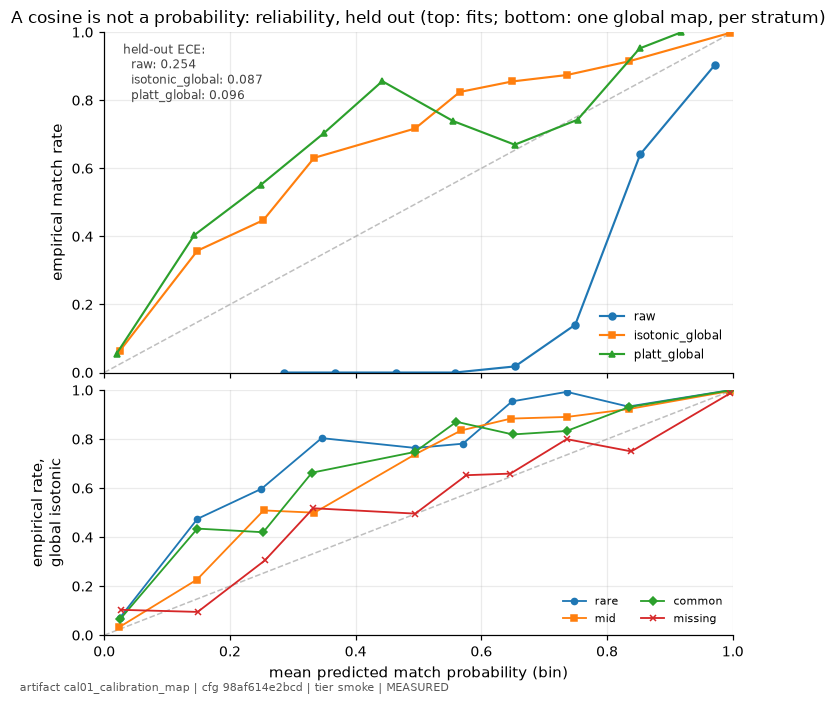

In [15]:
def draw_reliability(ax, df, meta):
    rel = df[(df["row_type"] == "reliability") & (df["stratum"] == "all")]
    ax.plot([0, 1], [0, 1], color="0.75", linewidth=1.0, linestyle="--", zorder=1)
    for fit, mark in (("raw", "o"), ("isotonic_global", "s"), ("platt_global", "^")):
        g = rel[rel["fit"] == fit].sort_values("p_mean")
        ax.plot(g["p_mean"], g["y_rate"], marker=mark, markersize=4.5, linewidth=1.4,
                label=fit)
    e = df[(df["row_type"] == "ece") & (df["stratum"] == "all")].set_index("fit")["ece"]
    ax.text(0.03, 0.97, "held-out ECE:\n" + "\n".join(
        f"  {f}: {e[f]:.3f}" for f in ("raw", "isotonic_global", "platt_global")),
        transform=ax.transAxes, fontsize=8, va="top", color="0.25")
    ax.set_ylabel("empirical match rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right", fontsize=8)
    ax.tick_params(axis="x", labelbottom=False)
    # lower panel: the SAME global isotonic map read per stratum — residual heterogeneity
    axs = make_axes_locatable(ax).append_axes("bottom", size="72%", pad=0.16, sharex=ax)
    axs.plot([0, 1], [0, 1], color="0.75", linewidth=1.0, linestyle="--", zorder=1)
    for st, mark in (("rare", "o"), ("mid", "s"), ("common", "D"), ("missing", "x")):
        g = df[(df["row_type"] == "reliability") & (df["fit"] == "isotonic_global")
               & (df["stratum"] == st)].sort_values("p_mean")
        if len(g):
            axs.plot(g["p_mean"], g["y_rate"], marker=mark, markersize=4, linewidth=1.2,
                     label=st)
    axs.set_xlabel("mean predicted match probability (bin)")
    axs.set_ylabel("empirical rate,\nglobal isotonic")
    axs.set_ylim(0, 1)
    axs.legend(loc="lower right", fontsize=7.5, ncols=2)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="cal01_calibration_map", draw=draw_reliability,
    title="A cosine is not a probability: reliability, held out (top: fits; "
          "bottom: one global map, per stratum)",
    figsize=(6.8, 6.4),
)

### Verdict — scoring the CAL-01 card against the registered numbers

In [16]:
p1 = bool(ECE_RAW >= 0.10 and ECE_ISO <= 0.03)
_ece_iso_g_common = float(ECE_TAB.loc["isotonic_global", "common"])
_ece_iso_s_common = float(ECE_TAB.loc["isotonic_strat", "common"])
p2 = bool(_ece_iso_g_common > _ece_iso_s_common)
# where does any isotonic shortfall live — fit capacity, or transfer to unseen entities?
ECE_ISO_IN = ece(cal_iso_g.transform(calfit["cos"].to_numpy()), calfit["label"].to_numpy())
print(f"transfer diagnostic: the SAME global isotonic map scores ECE {ECE_ISO_IN:.4f} "
      f"in-sample (calfit) vs {ECE_ISO:.4f} held out — any shortfall against the 0.03 bar "
      "is entity-to-entity score-distribution shift (calibration transfer), not binning "
      "capacity: isotonic is near-perfect where it was fitted")

_thr = thr_df.set_index("stratum")
if bool(_thr.loc["common", "attained"]) and bool(_thr.loc["rare", "attained"]):
    P3_AT = PAIR_PREC_TARGET
    t_common = float(_thr.loc["common", "threshold_cos"])
    t_rare = float(_thr.loc["rare", "threshold_cos"])
else:
    P3_AT = min(float(_thr.loc["common", "max_attainable"]),
                float(_thr.loc["rare", "max_attainable"]), PAIR_PREC_TARGET)
    print(f"P3 fallback engaged: comparing at the highest jointly-attainable precision "
          f"{P3_AT:.4f} (card's stated rail)")
    t_common = precision_threshold(_ev_cos[_ev_strat == "common"],
                                   _ev_label[_ev_strat == "common"], P3_AT)["threshold"]
    t_rare = precision_threshold(_ev_cos[_ev_strat == "rare"],
                                 _ev_label[_ev_strat == "rare"], P3_AT)["threshold"]
p3 = bool(t_common > t_rare)
refuted = bool(ECE_RAW < 0.03 or t_common <= t_rare)

print(f"P1 (global fix): raw ECE {ECE_RAW:.4f} (>= 0.10?) and isotonic_global ECE "
      f"{ECE_ISO:.4f} (<= 0.03?) -> {p1}")
print(f"P2 (residual heterogeneity, subordinate): common-stratum ECE under global isotonic "
      f"{_ece_iso_g_common:.4f} vs per-stratum isotonic {_ece_iso_s_common:.4f} -> {p2}")
print(f"P3 (common-name discount): threshold@{P3_AT:g} common {t_common:.4f} vs rare "
      f"{t_rare:.4f} (delta {t_common - t_rare:+.4f}) -> {p3}")
cal01_outcome = "REFUTED" if refuted else ("CONFIRMED" if (p1 and p3) else "UNEXPLAINED")
print(f"-> outcome: {cal01_outcome}")

_ = verdict_box(
    "CAL-01",
    outcome=cal01_outcome,
    evidence=(
        f"cal01_calibration_map (tier {TIER}; {len(caleval):,} held-out pairs from an "
        f"entity-disjoint calibration split within the train half; {CAL_BINS} bins). "
        f"P1 {p1}: raw (cos+1)/2 ECE {ECE_RAW:.4f} vs the 0.10 bar; global isotonic "
        f"{ECE_ISO:.4f} vs the 0.03 bar (Platt {ECE_PLATT:.4f} for context — a logistic "
        "in cosine cannot bend to the score mass the way isotonic does). Transfer "
        f"diagnostic: the same isotonic map scores {ECE_ISO_IN:.4f} in-sample — so any "
        "shortfall against the 0.03 bar is score-distribution shift onto unseen entities "
        "(calibration transfer), not fit capacity. "
        f"P2 {p2} (subordinate): common-tercile held-out ECE {_ece_iso_g_common:.4f} under "
        f"the global isotonic map vs {_ece_iso_s_common:.4f} under the per-stratum fit. "
        f"P3 {p3}: pairwise-precision-{P3_AT:g} raw-cosine thresholds — common "
        f"{t_common:.4f}, rare {t_rare:.4f} (attained flags: common "
        f"{bool(_thr.loc['common', 'attained'])}, rare {bool(_thr.loc['rare', 'attained'])}"
        "; fallback rail engaged only if a flag is False). The same cosine is worth less "
        "between common family names — the registered per-stratum thresholds price the "
        "discount for NB14's rule arbitration. DEMONSTRATION, not adjudication: one "
        f"encoder (seed {PRIMARY_SEED}), one corpus draw; the MET-04 residual-inclusive "
        f"replicate bar is {BAR_FULL:.4f} B³F1 ({BAR_SRC}) — CAL-01's definitive run is "
        "tier=mid on the mac (PLAN §3)."
    ),
    registry=registry,
)

transfer diagnostic: the SAME global isotonic map scores ECE 0.0000 in-sample (calfit) vs 0.0872 held out — any shortfall against the 0.03 bar is entity-to-entity score-distribution shift (calibration transfer), not binning capacity: isotonic is near-perfect where it was fitted
P1 (global fix): raw ECE 0.2545 (>= 0.10?) and isotonic_global ECE 0.0872 (<= 0.03?) -> False
P2 (residual heterogeneity, subordinate): common-stratum ECE under global isotonic 0.0937 vs per-stratum isotonic 0.0848 -> True
P3 (common-name discount): threshold@0.99 common 0.9079 vs rare 0.8905 (delta +0.0174) -> True
-> outcome: UNEXPLAINED


> ### VERDICT: UNEXPLAINED — card `CAL-01`
>
> **Conjecture** A cosine is not a probability: read naively as one, the trained encoder's raw similarity is badly miscalibrated on held-out pairs; isotonic regression fixes the global score->probability map, but per name-frequency strata the residual heterogeneity survives — the same cosine means less between common family names than between rare ones, so common names need a higher threshold for the same precision (the common-name discount).
>
> **Prediction** P1: raw cosine read as (cos+1)/2 has held-out ECE >= 0.10 while the global isotonic map's held-out ECE is <= 0.03 (all-pairs stratum). P2 (subordinate, cannot flip the outcome): under the GLOBAL isotonic map the common tercile's held-out ECE exceeds the per-stratum isotonic fit's common-tercile ECE — residual heterogeneity a single global map cannot remove. P3: the raw-cosine threshold attaining pairwise precision 0.99 is strictly higher for the common tercile than for the rare tercile; if either stratum cannot attain 0.99 (PLAN §5 highest-attainable fallback, flagged loudly), P3 is read at the highest precision attainable in BOTH strata. Decision rule, pre-registered: CONFIRMED iff P1 and P3 both hold; REFUTED iff raw ECE < 0.03 (nothing to fix) or the common-tercile threshold at the P3 comparison point is <= the rare-tercile threshold; UNEXPLAINED otherwise. One encoder, one seed, one corpus draw: whatever the outcome, this is a demonstration — CAL-01's definitive home is the mid tier (PLAN §3).
>
> **Evidence** cal01_calibration_map (tier smoke; 60,040 held-out pairs from an entity-disjoint calibration split within the train half; 10 bins). P1 False: raw (cos+1)/2 ECE 0.2545 vs the 0.10 bar; global isotonic 0.0872 vs the 0.03 bar (Platt 0.0963 for context — a logistic in cosine cannot bend to the score mass the way isotonic does). Transfer diagnostic: the same isotonic map scores 0.0000 in-sample — so any shortfall against the 0.03 bar is score-distribution shift onto unseen entities (calibration transfer), not fit capacity. P2 True (subordinate): common-tercile held-out ECE 0.0937 under the global isotonic map vs 0.0848 under the per-stratum fit. P3 True: pairwise-precision-0.99 raw-cosine thresholds — common 0.9079, rare 0.8905 (attained flags: common True, rare True; fallback rail engaged only if a flag is False). The same cosine is worth less between common family names — the registered per-stratum thresholds price the discount for NB14's rule arbitration. DEMONSTRATION, not adjudication: one encoder (seed 17), one corpus draw; the MET-04 residual-inclusive replicate bar is 0.0865 B³F1 (read from met04_power_table meta) — CAL-01's definitive run is tier=mid on the mac (PLAN §3).


## 6. CLU-01, the conjecture — registered before any clustering runs

Notebook 07 priced the guards on a graph that refused to percolate and left CLU-01 the
open question: does scheme choice start to *matter* once the candidate graph is dense and
the scores are an encoder's? The card commits to the skeptical reading — at protocol
operating points, scheme choice moves entity-F less than replicate noise — with the MET-04
bar as the pre-registered yardstick and the percolation view as the mechanism check.

In [17]:
_ = conjecture_card(
    card_id="CLU-01",
    conjecture=(
        "At fixed-precision operating points, the clustering scheme is a second-order "
        "choice on this corpus: with calibrated dense-candidate scores, transitive closure, "
        "capped agglomerative, star clustering, and greedy correlation land within "
        "replicate noise of each other on entity-level F — even though the dense candidate "
        "graph, unlike NB07's starved matchkey/FS graph, genuinely percolates at low "
        "thresholds (where the guards' insurance finally has something to pay out on)."
    ),
    pressure=(
        "clustering scheme over FIXED calibrated scores: {transitive_closure, "
        "capped_agglomerative (cap = the corpus meta's dup_dist.max cluster-size prior), "
        "star_clustering, greedy_correlation (KwikCluster on log-odds sign, seeded)} on "
        "the SAME scored pairs — dense ANN top-10 candidates over the entity-disjoint EVAL "
        "half, cosine-scored by the identically-retrained NB12-recipe encoder, mapped to "
        "probabilities by CAL-01's global isotonic calibrator — at the PLAN §5 operating "
        "points: fixed B-cubed entity-precision {0.99, 0.995} per scheme (loosest "
        "threshold attaining the target; highest-attainable fallback flagged loudly) plus "
        "the explicit cost grid {1:1, 10:1, 100:1 FP:FN}"
    ),
    property=(
        "graph-structural, not embedding-geometric: the percolation profile of the "
        "calibrated candidate graph — worst-component true-entity count and accepted-pair "
        "precision across a threshold sweep of transitive closure, with the entity-graph "
        "mean cross-entity degree as the Erdős–Rényi giant-component onset heuristic "
        "(mean degree ≈ 1), compared in shape against chain_merge_demo's registered FS/"
        "matchkey sweep from notebook 07"
    ),
    metric=(
        "B-cubed precision/recall/F1 with entity-unit BCa 95% CIs per scheme at each "
        "operating point, paired entity-bootstrap deltas on shared resamples between "
        "schemes, worst-fusion counts, and the sweep rows — all registered in "
        "clu01_clustering_scores"
    ),
    prediction=(
        "P1: at the precision@0.99 operating point (each scheme at its own loosest "
        "threshold attaining B-cubed precision 0.99), the max-minus-min B-cubed F1 across "
        "the four schemes is smaller than the MET-04 residual-inclusive single-seed bar "
        "read from met04_power_table meta at this tier. P2: the same at precision@0.995. "
        "P3 (subordinate, cannot flip the outcome): the dense candidate graph percolates "
        "where NB07's did not — the sweep's worst-component true-entity count exceeds "
        "chain_merge_demo's sweep maximum, with onset near the entity-graph mean-degree=1 "
        "heuristic — while at the precision operating points themselves every scheme stays "
        "below chain_merge_demo's catastrophe line (>= 20 entities fused). Decision rule, "
        "pre-registered: REFUTED iff at either fixed-precision point some scheme pair's "
        "B-cubed F1 delta has |delta| >= the bar AND its paired entity-BCa 95% CI excludes "
        "zero; CONFIRMED iff P1 and P2 both hold with every scheme actually attaining the "
        "target (an operating point where any scheme falls back to highest-attainable "
        "precision cannot CONFIRM — it can only REFUTE or leave UNEXPLAINED); UNEXPLAINED "
        "otherwise. Cost-grid points are reported, not scored. Single seed, one corpus "
        "draw, ~1.6e4-record eval half: a demonstration — hub resistance and this card's "
        "adjudication are the tier=target run at 1e7 (placard below)."
    ),
    registry=registry,
)

### Conjecture card `CLU-01`

| | |
|---|---|
| **Conjecture** | At fixed-precision operating points, the clustering scheme is a second-order choice on this corpus: with calibrated dense-candidate scores, transitive closure, capped agglomerative, star clustering, and greedy correlation land within replicate noise of each other on entity-level F — even though the dense candidate graph, unlike NB07's starved matchkey/FS graph, genuinely percolates at low thresholds (where the guards' insurance finally has something to pay out on). |
| **Pressure (dial)** | clustering scheme over FIXED calibrated scores: {transitive_closure, capped_agglomerative (cap = the corpus meta's dup_dist.max cluster-size prior), star_clustering, greedy_correlation (KwikCluster on log-odds sign, seeded)} on the SAME scored pairs — dense ANN top-10 candidates over the entity-disjoint EVAL half, cosine-scored by the identically-retrained NB12-recipe encoder, mapped to probabilities by CAL-01's global isotonic calibrator — at the PLAN §5 operating points: fixed B-cubed entity-precision {0.99, 0.995} per scheme (loosest threshold attaining the target; highest-attainable fallback flagged loudly) plus the explicit cost grid {1:1, 10:1, 100:1 FP:FN} |
| **Embedding property** | graph-structural, not embedding-geometric: the percolation profile of the calibrated candidate graph — worst-component true-entity count and accepted-pair precision across a threshold sweep of transitive closure, with the entity-graph mean cross-entity degree as the Erdős–Rényi giant-component onset heuristic (mean degree ≈ 1), compared in shape against chain_merge_demo's registered FS/matchkey sweep from notebook 07 |
| **System metric** | B-cubed precision/recall/F1 with entity-unit BCa 95% CIs per scheme at each operating point, paired entity-bootstrap deltas on shared resamples between schemes, worst-fusion counts, and the sweep rows — all registered in clu01_clustering_scores |
| **Pre-registered prediction** | P1: at the precision@0.99 operating point (each scheme at its own loosest threshold attaining B-cubed precision 0.99), the max-minus-min B-cubed F1 across the four schemes is smaller than the MET-04 residual-inclusive single-seed bar read from met04_power_table meta at this tier. P2: the same at precision@0.995. P3 (subordinate, cannot flip the outcome): the dense candidate graph percolates where NB07's did not — the sweep's worst-component true-entity count exceeds chain_merge_demo's sweep maximum, with onset near the entity-graph mean-degree=1 heuristic — while at the precision operating points themselves every scheme stays below chain_merge_demo's catastrophe line (>= 20 entities fused). Decision rule, pre-registered: REFUTED iff at either fixed-precision point some scheme pair's B-cubed F1 delta has |delta| >= the bar AND its paired entity-BCa 95% CI excludes zero; CONFIRMED iff P1 and P2 both hold with every scheme actually attaining the target (an operating point where any scheme falls back to highest-attainable precision cannot CONFIRM — it can only REFUTE or leave UNEXPLAINED); UNEXPLAINED otherwise. Cost-grid points are reported, not scored. Single seed, one corpus draw, ~1.6e4-record eval half: a demonstration — hub resistance and this card's adjudication are the tier=target run at 1e7 (placard below). |

*Immutable — sha256 `a7653a58d617`; registered before the affected runs, never edited (PLAN §5).*


## 7. The eval-half calibrated candidate graph

Candidates are dense ANN top-k (`K_CAND`) over the eval half's embeddings — the graph BAS-02
measured at this exact budget, and the graph notebook 07 warned is percolation fuel.
Scores are raw cosines pushed through **CAL-01's global isotonic map** (the calibrator
whose held-out ECE was just measured; fitted on calfit only). Two honest notes, stated
before the numbers: (a) for the threshold-dial schemes the isotonic map is only *weakly*
monotone — piecewise-constant, many-to-one — so it **coarsens** the attainable partition
set: distinct cosines mapped onto the same probability step can never again be separated
by any threshold, and the threshold grid can only cut where the map steps (the distinct-
value count is measured in the output below). Clustering calibrated probabilities anyway
is a stated protocol choice — CLU-01's question is what the schemes do with the
probabilities the pipeline actually hands them, and a threshold on that scale means
something — not a claim of partition-invariance; (b) for greedy correlation the map is
load-bearing — its prob > 0.5 attraction rule reads the absolute probability scale,
which is exactly what calibration exists to make true.

In [18]:
t_sec = time.time()
ev_pos = ARENA_POS.loc[eval_full["record_id"].astype(str)].to_numpy()
_t0 = time.time()
cand_ev = ann.candidates(eval_full, EMB[ev_pos], k=K_CAND, index="flat")
CAND_SECS = time.time() - _t0
truth_ev = eval_full.set_index(eval_full["record_id"].astype(str))["entity_id"]
records_ev = pd.Index(truth_ev.index)
N_EV = len(records_ev)
N_ENT_EV = int(truth_ev.nunique())

ev_scored = cand_ev[["a", "b"]].copy()
ev_scored["a"], ev_scored["b"] = ev_scored["a"].astype(str), ev_scored["b"].astype(str)
ev_scored["cos"] = pair_cosines(ev_scored["a"], ev_scored["b"])
ev_scored["prob"] = cal_iso_g.transform(ev_scored["cos"].to_numpy())
ev_scored["score"] = ev_scored["prob"]
edge_true_ev = (
    truth_ev.loc[ev_scored["a"]].to_numpy() == truth_ev.loc[ev_scored["b"]].to_numpy()
)
bm_ev = blocking_metrics(cand_ev, truth_ev, n_records=N_EV)
N_TRUE_PAIRS_EV = int(bm_ev["n_true_pairs"])
PC_EV = float(bm_ev["pair_completeness"])
_cm_pc_m = re.search(r"pair completeness ([0-9.]+)",
                     cm_meta["extra"]["edge_metric_definitions"]["edge_recall"])
CM_PC = float(_cm_pc_m.group(1)) if _cm_pc_m else float("nan")
FUSE_CATASTROPHE = int(cm_meta["extra"]["protocol_constants"]["fuse_catastrophe"])
PW_FLOOR = float(cm_meta["extra"]["protocol_constants"]["pw_floor"])
CM_SWEEP = cm_demo[cm_demo["row_type"] == "sweep"]
CM_MAX_FUSED = int(CM_SWEEP["max_entities_fused"].max())

print(f"eval candidate graph: ann_flat k={K_CAND} over {N_EV:,} records "
      f"({N_ENT_EV:,} entities) -> {len(ev_scored):,} pairs in {CAND_SECS:.1f}s")
print(f"  pair completeness {PC_EV:.4f} of {N_TRUE_PAIRS_EV:,} true pairs "
      f"(vs NB07's matchkey graph at {CM_PC:.4f}); candidate edge precision at t=0: "
      f"{edge_true_ev.mean():.4f} (vs NB07's {CM_SWEEP['edge_precision'].min():.4f} floor "
      "— the dense graph carries far more cross-entity fuel)")
print(f"  calibrated probs: {ev_scored['prob'].min():.4f}..{ev_scored['prob'].max():.4f}, "
      f"{ev_scored['prob'].nunique()} distinct values (isotonic is piecewise-constant — "
      "the threshold grid can only cut where the map steps)")
print(f"  NB07 constants inherited from chain_merge_demo meta: catastrophe >= "
      f"{FUSE_CATASTROPHE} entities fused, accepted-pair precision floor {PW_FLOOR}; "
      f"NB07's sweep max fusion was {CM_MAX_FUSED}")
tick("§7 candidate graph + calibrate", t_sec)

eval candidate graph: ann_flat k=10 over 16,095 records (1,255 entities) -> 112,070 pairs in 2.4s
  pair completeness 0.3716 of 187,785 true pairs (vs NB07's matchkey graph at 0.5343); candidate edge precision at t=0: 0.6227 (vs NB07's 0.9529 floor — the dense graph carries far more cross-entity fuel)
  calibrated probs: 0.1491..1.0000, 60 distinct values (isotonic is piecewise-constant — the threshold grid can only cut where the map steps)
  NB07 constants inherited from chain_merge_demo meta: catastrophe >= 20 entities fused, accepted-pair precision floor 0.9; NB07's sweep max fusion was 4
[section timing] §7 candidate graph + calibrate: 3s


## 8. Four schemes at the protocol operating points

Each scheme is swept over the same calibrated-score grid with a cache-backed clusterer
(`find_threshold_for_precision` / `cost_optimal_threshold` re-sweep internally; the cache
makes the clusterings shared). `greedy_correlation` is threshold-free by design (its rule
is prob > 0.5), so its dial is a pre-filter of the pair list at t — below 0.5 the filter
is inert and the curve is flat, which is itself the honest reading of a scheme that
refuses the dial. Every operating point carries B-cubed point + entity-unit BCa 95% CI,
fusion counts, and the loud fallback flag wherever a target is unattainable.

In [19]:
t_sec = time.time()
SCHEMES = ("transitive_closure", "capped_agglomerative", "star_clustering",
           "greedy_correlation")
SCHEME_FN = {
    "transitive_closure": lambda t: transitive_closure(
        ev_scored, threshold=t, records=records_ev),
    "capped_agglomerative": lambda t: capped_agglomerative(
        ev_scored, threshold=t, cap=CAP, records=records_ev),
    "star_clustering": lambda t: star_clustering(ev_scored, threshold=t, records=records_ev),
    "greedy_correlation": lambda t: greedy_correlation(
        ev_scored[ev_scored["prob"] >= t], records=records_ev, seed=PRIMARY_SEED),
}
PRED_CACHE: dict[tuple[str, float], pd.Series] = {}
PRED_SECS: dict[tuple[str, float], float] = {}


def pred_at(scheme: str, thr: float) -> pd.Series:
    thr = float(thr)
    # below 0.5 greedy's prob>0.5 rule makes the pre-filter inert: one cache entry
    key = (scheme, max(thr, 0.5) if scheme == "greedy_correlation" else thr)
    if key not in PRED_CACHE:
        t0 = time.time()
        PRED_CACHE[key] = SCHEME_FN[scheme](thr)
        PRED_SECS[key] = time.time() - t0
    return PRED_CACHE[key]


CI_METRICS = (("precision", "bcubed_precision"), ("recall", "bcubed_recall"),
              ("f1", "bcubed_f1"))


def op_row(scheme: str, protocol: str, thr: float, **extra) -> dict:
    pred = pred_at(scheme, thr)
    ents = truth_ev.groupby(pred).nunique()
    key = (scheme, max(float(thr), 0.5) if scheme == "greedy_correlation" else float(thr))
    row = {"row_type": "op", "scheme": scheme, "protocol": protocol,
           "threshold": float(thr),
           "pairs_kept": int((ev_scored["prob"] >= thr).sum()),
           "n_clusters": int(pred.nunique()), "max_entities_fused": int(ents.max()),
           "runtime_s": PRED_SECS[key], "attained": np.nan, "fallback": "",
           "cost": np.nan, "pair_fp": np.nan, "pair_fn": np.nan, "basis": "MEASURED"}
    for short, metric in CI_METRICS:
        res = bootstrap_ci(pred, truth_ev, metric, unit="entity", n_boot=N_BOOT,
                           seed=PRIMARY_SEED)
        row[short] = res["point"]
        row[f"{short}_lo"] = res["ci_low"]
        row[f"{short}_hi"] = res["ci_high"]
    row.update(extra)
    return row


op_rows: list[dict] = []
spairs = ev_scored[["a", "b", "score"]]
for scheme in SCHEMES:
    for target in PREC_TARGETS:
        res = find_threshold_for_precision(
            spairs, lambda t, s=scheme: pred_at(s, t), truth_ev, target=target, grid=GRID)
        op_rows.append(op_row(scheme, f"precision@{target}", res["threshold"],
                              attained=float(res["attained"]),
                              fallback=res["fallback"] or ""))
        flag = "" if res["attained"] else (
            "  <-- TARGET UNATTAINABLE on this eval set: fallback="
            f"'{res['fallback']}' (PLAN §5 rail: report loudly, never switch silently)")
        print(f"[{scheme}] precision@{target}: t={res['threshold']:.6f} "
              f"attained P={res['attained_precision']:.4f} R={res['recall_at']:.4f}{flag}")
    for fp_cost, fn_cost in COST_GRID:
        res = cost_optimal_threshold(
            spairs, lambda t, s=scheme: pred_at(s, t), truth_ev,
            fp_cost=fp_cost, fn_cost=fn_cost, grid=GRID)
        op_rows.append(op_row(scheme, f"cost@{fp_cost}:{fn_cost}", res["threshold"],
                              cost=res["cost"], pair_fp=res["fp"], pair_fn=res["fn"]))
        print(f"[{scheme}] cost {fp_cost}:{fn_cost} -> t={res['threshold']:.6f} "
              f"cost={res['cost']:,.0f} (FP={res['fp']:,.0f} FN={res['fn']:,.0f}) "
              f"P={res['precision']:.4f} R={res['recall']:.4f}")
ops = pd.DataFrame(op_rows)
print(f"\n{len(ops)} operating points ({len(SCHEMES)} schemes x "
      f"{len(PREC_TARGETS) + len(COST_GRID)} protocols) + entity-unit BCa CIs "
      f"({N_BOOT} replicates x 3 metrics): {time.time() - t_sec:.0f}s")
display(ops[ops["protocol"].str.startswith("precision")]
        [["scheme", "protocol", "threshold", "attained", "precision", "recall", "f1",
          "f1_lo", "f1_hi", "max_entities_fused", "n_clusters"]].round(4))
tick("§8 operating points + CIs", t_sec)

[transitive_closure] precision@0.99: t=0.991043 attained P=0.9911 R=0.4009


[transitive_closure] precision@0.995: t=0.993559 attained P=0.9981 R=0.3913


[transitive_closure] cost 1:1 -> t=0.993559 cost=126,709 (FP=167 FN=126,542) P=0.9981 R=0.3913


[transitive_closure] cost 10:1 -> t=0.993559 cost=128,212 (FP=167 FN=126,542) P=0.9981 R=0.3913


[transitive_closure] cost 100:1 -> t=0.995044 cost=131,932 (FP=15 FN=130,432) P=0.9993 R=0.3721


...

[greedy_correlation] cost 1:1 -> t=0.793103 cost=138,390 (FP=2,114 FN=136,276) P=0.9717 R=0.3697


[greedy_correlation] cost 10:1 -> t=0.965285 cost=142,535 (FP=286 FN=139,675) P=0.9945 R=0.3478


[greedy_correlation] cost 100:1 -> t=0.996271 cost=146,287 (FP=13 FN=144,987) P=0.9994 R=0.3165

20 operating points (4 schemes x 5 protocols) + entity-unit BCa CIs (500 replicates x 3 metrics): 36s


,scheme,protocol,threshold,attained,precision,recall,f1,f1_lo,f1_hi,max_entities_fused,n_clusters
0,transitive_closure,precision@0.99,0.9910,1.0,0.9911,0.4009,0.5709,0.5571,0.5847,9,5134
1,transitive_closure,precision@0.995,0.9936,1.0,0.9981,0.3913,0.5622,0.5487,0.5769,4,5276
5,capped_agglomerative,precision@0.99,0.9653,1.0,0.9905,0.4016,0.5715,0.5593,0.5840,6,4951
6,capped_agglomerative,precision@0.995,0.9910,1.0,0.9967,0.3788,0.5489,0.5361,0.5615,5,5280
10,star_clustering,precision@0.99,0.9604,1.0,0.9916,0.4141,0.5842,0.5702,0.5963,6,4900
11,star_clustering,precision@0.995,0.9910,1.0,0.9975,0.3905,0.5613,0.5492,0.5743,4,5220
15,greedy_correlation,precision@0.99,0.9555,1.0,0.9927,0.3527,0.5205,0.5060,0.5338,5,5543
16,greedy_correlation,precision@0.995,0.9890,1.0,0.9976,0.3340,0.5005,0.4875,0.5128,4,5920


[section timing] §8 operating points + CIs: 36s


## 9. The percolation view — NB07's sweep, re-run where the fuel is

The identical two-dashboard sweep notebook 07 ran on the starved FS/matchkey graph, now on
the dense calibrated graph: transitive closure per threshold, worst-component true-entity
count next to accepted-pair precision, plus the onset instrument — the **entity-graph mean
degree** (distinct cross-entity accepted edges, contracted to entities; the Erdős–Rényi
giant-component heuristic says fusion percolates when it crosses ~1). The paired deltas the
card's decision rule needs are computed here too, on shared entity resamples.

In [20]:
t_sec = time.time()
prob_ev = ev_scored["prob"].to_numpy()
# one shared factorization for entity-pair keys (cross edges only)
_ea_all = truth_ev.loc[ev_scored["a"]].to_numpy()
_eb_all = truth_ev.loc[ev_scored["b"]].to_numpy()
_codes, _ = pd.factorize(np.concatenate([_ea_all, _eb_all]))
_ca, _cb = _codes[: len(ev_scored)], _codes[len(ev_scored):]
_cross = _ca != _cb
_ekey = (np.minimum(_ca, _cb).astype(np.int64) * (int(_codes.max()) + 2)
         + np.maximum(_ca, _cb))

_quants = np.round(np.quantile(prob_ev, np.linspace(0.0, 1.0, SWEEP_N)), 8)
_t99 = {r["scheme"]: r["threshold"] for _, r in
        ops[ops["protocol"] == f"precision@{PREC_TARGETS[0]}"].iterrows()}
sweep_thresholds = np.unique(np.concatenate(
    [np.asarray(ANCHOR_THRESHOLDS), _quants, np.asarray(list(_t99.values()))]))
sweep_thresholds = sweep_thresholds[(sweep_thresholds >= 0) & (sweep_thresholds <= 1)]

sweep_rows: list[dict] = []
for thr in sweep_thresholds:
    kept = prob_ev >= thr
    n_kept = int(kept.sum())
    pred = pred_at("transitive_closure", float(thr))
    sizes = pred.value_counts()
    ents_per = truth_ev.groupby(pred).nunique()
    b3 = bcubed(pred, truth_ev)
    pw = pairwise(pred, truth_ev)
    n_cross_kept = int((kept & _cross).sum())
    ent_edges = int(pd.unique(_ekey[kept & _cross]).size)
    sweep_rows.append({
        "row_type": "sweep", "scheme": "transitive_closure", "threshold": float(thr),
        "pairs_kept": n_kept,
        "edge_precision": float(edge_true_ev[kept].mean()) if n_kept else np.nan,
        "edge_recall": float(edge_true_ev[kept].sum() / N_TRUE_PAIRS_EV),
        "n_components": len(sizes),
        "largest_comp_records": int(sizes.iloc[0]) if len(sizes) else 0,
        "max_entities_fused": int(ents_per.max()),
        "n_comps_fusing_gt10": int((ents_per > 10).sum()),
        "mean_cross_degree_records": 2.0 * n_cross_kept / N_EV,
        "entity_graph_mean_degree": 2.0 * ent_edges / N_ENT_EV,
        "bcubed_precision": b3["precision"], "bcubed_recall": b3["recall"],
        "bcubed_f1": b3["f1"],
        "pairwise_precision": pw["precision"], "pairwise_recall": pw["recall"],
        "pairwise_f1": pw["f1"], "basis": "MEASURED",
    })
sweep = pd.DataFrame(sweep_rows).sort_values("threshold").reset_index(drop=True)

_onset = sweep[sweep["entity_graph_mean_degree"] >= 1.0]
ONSET_T = float(_onset["threshold"].max()) if len(_onset) else np.nan
MAX_FUSED_SWEEP = int(sweep["max_entities_fused"].max())
_worst = sweep.loc[sweep["max_entities_fused"].idxmax()]
print(f"{len(sweep)} thresholds swept; worst closure fusion "
      f"{MAX_FUSED_SWEEP} true entities in one component (t={_worst['threshold']:.4f}, "
      f"edge precision {_worst['edge_precision']:.4f}) vs NB07's sweep max "
      f"{CM_MAX_FUSED} and the >= {FUSE_CATASTROPHE} catastrophe line")
if np.isfinite(ONSET_T):
    _fuse_at_onset = int(
        sweep.loc[sweep["threshold"] == ONSET_T, "max_entities_fused"].iloc[0])
    print(f"entity-graph mean degree crosses 1 at t ~ {ONSET_T:.4f} (ER giant-component "
          f"heuristic); worst fusion at that threshold: {_fuse_at_onset} entities")
else:
    print("entity-graph mean degree never reaches 1 anywhere in the sweep — no "
          "percolation regime on this graph (the NB07 situation all over again)")
_t99_min = min(_t99.values())
_onset_read = ("ABOVE" if np.isfinite(ONSET_T) and _t99_min > ONSET_T
               else "AT/BELOW" if np.isfinite(ONSET_T) else "moot: no onset —")
print(f"all precision@{PREC_TARGETS[0]} operating thresholds "
      f"({', '.join(f'{k}={v:.3f}' for k, v in _t99.items())}) sit "
      f"{_onset_read} the percolation onset")
display(sweep[["threshold", "pairs_kept", "edge_precision", "max_entities_fused",
               "entity_graph_mean_degree", "bcubed_precision", "bcubed_recall"]]
        .round(4).head(12))

27 thresholds swept; worst closure fusion 1254 true entities in one component (t=0.0000, edge precision 0.6227) vs NB07's sweep max 4 and the >= 20 catastrophe line
entity-graph mean degree crosses 1 at t ~ 0.7000 (ER giant-component heuristic); worst fusion at that threshold: 324 entities
all precision@0.99 operating thresholds (transitive_closure=0.991, capped_agglomerative=0.965, star_clustering=0.960, greedy_correlation=0.955) sit ABOVE the percolation onset


,threshold,pairs_kept,edge_precision,max_entities_fused,entity_graph_mean_degree,bcubed_precision,bcubed_recall
0,0.0000,112070,0.6227,1254,17.1394,0.0160,0.9873
1,0.0100,112070,0.6227,1254,17.1394,0.0160,0.9873
2,0.0500,112070,0.6227,1254,17.1394,0.0160,0.9873
3,0.1000,112070,0.6227,1254,17.1394,0.0160,0.9873
4,0.1491,112066,0.6227,1254,17.1378,0.0160,0.9873
5,0.2000,112066,0.6227,1254,17.1378,0.0160,0.9873
6,0.3000,112054,0.6228,1254,17.1251,0.0168,0.9871
7,0.4000,112046,0.6229,1254,17.1219,0.0169,0.9870
8,0.4964,111988,0.6231,1253,17.0932,0.0170,0.9869
9,0.5000,73422,0.8557,754,3.8327,0.4972,0.6557


In [21]:
# Paired scheme deltas on shared entity resamples — the card's REFUTED clause instrument.
delta_rows: list[dict] = []
for target in PREC_TARGETS:
    proto = f"precision@{target}"
    trow = {r["scheme"]: r["threshold"] for _, r in
            ops[ops["protocol"] == proto].iterrows()}
    for i, sa in enumerate(SCHEMES):
        for sb in SCHEMES[i + 1:]:
            res = paired_delta(pred_at(sa, trow[sa]), pred_at(sb, trow[sb]), truth_ev,
                               "bcubed_f1", unit="entity", n_boot=N_BOOT,
                               seed=PRIMARY_SEED)
            delta_rows.append({
                "row_type": "delta", "protocol": proto, "scheme": sa, "scheme_b": sb,
                "delta_f1": res["delta"], "delta_lo": res["ci_low"],
                "delta_hi": res["ci_high"], "sign_stable": bool(res["sign_stable"]),
                "exceeds_bar": bool(abs(res["delta"]) >= BAR_FULL),
                "basis": "MEASURED",
            })
deltas = pd.DataFrame(delta_rows)
print(f"paired B³F1 deltas (shared entity resamples, {N_BOOT} replicates), vs the "
      f"residual-inclusive bar {BAR_FULL:.4f}:")
display(deltas[["protocol", "scheme", "scheme_b", "delta_f1", "delta_lo", "delta_hi",
                "sign_stable", "exceeds_bar"]].round(4))
tick("§9 percolation sweep + paired deltas", t_sec)

paired B³F1 deltas (shared entity resamples, 500 replicates), vs the residual-inclusive bar 0.0865:


,protocol,scheme,scheme_b,delta_f1,delta_lo,delta_hi,sign_stable,exceeds_bar
0,precision@0.99,transitive_closure,capped_agglomerative,-0.0006,-0.0092,0.0089,False,False
1,precision@0.99,transitive_closure,star_clustering,-0.0134,-0.0175,-0.0080,True,False
2,precision@0.99,transitive_closure,greedy_correlation,0.0503,0.0397,0.0647,True,False
3,precision@0.99,capped_agglomerative,star_clustering,-0.0128,-0.0198,-0.0066,True,False
4,precision@0.99,capped_agglomerative,greedy_correlation,0.0509,0.0412,0.0604,True,False
5,precision@0.99,star_clustering,greedy_correlation,0.0637,0.0548,0.0746,True,False
6,precision@0.995,transitive_closure,capped_agglomerative,0.0133,0.0067,0.0208,True,False
7,precision@0.995,transitive_closure,star_clustering,0.0009,-0.0026,0.0056,False,False
8,precision@0.995,transitive_closure,greedy_correlation,0.0618,0.0508,0.0742,True,False
9,precision@0.995,capped_agglomerative,star_clustering,-0.0124,-0.0179,-0.0070,True,False


[section timing] §9 percolation sweep + paired deltas: 4s


In [22]:
t_sec = time.time()
clu01 = pd.concat([ops, sweep, deltas], ignore_index=True)
registry.register(
    "clu01_clustering_scores", clu01, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "CLU-01",
        "row_types": {
            "op": "scheme x operating point (fixed precision + cost grid): threshold, "
                  "B-cubed point + entity-unit BCa 95% CI, fusion counts, runtime; "
                  "'attained'/'fallback' carry the PLAN §5 rail",
            "sweep": "transitive closure per threshold over the calibrated dense graph: "
                     "pair-decision view + entity view + percolation instruments "
                     "(mean_cross_degree_records, entity_graph_mean_degree)",
            "delta": "paired B³F1 deltas between schemes at the fixed-precision points, "
                     "shared entity resamples; exceeds_bar = |delta| >= the MET-04 "
                     "residual-inclusive bar",
        },
        "candidate_graph": {
            "method": f"ann_flat k={K_CAND} over the {SCHEME} EVAL half "
                      f"({N_EV} records / {N_ENT_EV} entities)",
            "pair_completeness": PC_EV, "n_true_pairs": N_TRUE_PAIRS_EV,
            "edge_precision_at_t0": float(edge_true_ev.mean()),
            "nb07_comparison": {"pc": CM_PC, "sweep_max_fused": CM_MAX_FUSED,
                                "constants_from": "chain_merge_demo meta"},
        },
        "scores": "raw cosine (identically-retrained NB12-recipe encoder, recipe in "
                  "cal01_calibration_map meta) -> CAL-01 global isotonic calibrator "
                  "(fitted on the calfit split only; held-out ECE in "
                  "cal01_calibration_map). Monotone for the threshold schemes; "
                  "load-bearing for greedy_correlation's prob>0.5 rule.",
        "schemes": {"cap": CAP, "cap_source": "calibrated_corpus meta dup_dist.max",
                    "greedy_dial": "pre-filter of the pair list at t (inert below 0.5 — "
                                   "the scheme's own log-odds-sign rule is the decision)",
                    "seed": PRIMARY_SEED},
        "protocol": {"precision_targets": list(PREC_TARGETS),
                     "cost_grid_fp_fn": [list(c) for c in COST_GRID], "grid": GRID,
                     "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT,
                            "seed": PRIMARY_SEED},
                     "pairs_kept": "count of candidate pairs with prob >= threshold "
                                   "(for greedy the effective graph is prob > max(t, 0.5))"},
        "percolation": {"onset_heuristic": "entity-graph mean degree >= 1 (Erdős–Rényi "
                                           "giant-component criterion, contracted to "
                                           "entities; a heuristic reference, the graph is "
                                           "not ER)",
                        "onset_threshold": ONSET_T,
                        "max_fused_in_sweep": MAX_FUSED_SWEEP},
        "met04": {"sd_replicate": SD_REPLICATE, "residual_inclusive_bar": BAR_FULL,
                  "bar_source": BAR_SRC, "units": "B3F1"},
        "single_seed_caveat": "one trained encoder, one seed, one corpus draw — a "
                              "DEMONSTRATION; the definitive hub-resistance run is "
                              "tier=target at 1e7 (placard below)",
        "corpus_provenance": CORPUS_PROVENANCE,
        "upstream": {"bas02": BAS02_PROVENANCE,
                     "chain_merge_demo": f"run {cm_meta['created_at']} "
                                         f"(cfg {cm_meta['config_hash']})"},
    },
)
print(f"registered clu01_clustering_scores: {len(ops)} op rows + {len(sweep)} sweep rows "
      f"+ {len(deltas)} delta rows")
tick("§9b register", t_sec)

registered clu01_clustering_scores: 20 op rows + 27 sweep rows + 12 delta rows
[section timing] §9b register: 0s


## 10. Drawn: the scheme ledger and the two percolation panels

The scheme figure puts every fixed-precision operating point in F-with-CI space with the
MET-04 bar drawn as the bracket the card is scored against. The percolation comparison
renders as **two aligned panels** — one from `clu01_clustering_scores`, one from NB07's
`chain_merge_demo` — because the figure rail stamps provenance per artifact and a single
axes cannot honestly carry two artifacts' stamps (multi-artifact stamping is a package
gap, noted); both panels share axis limits, set from this run's sweep, so shape reads
across.

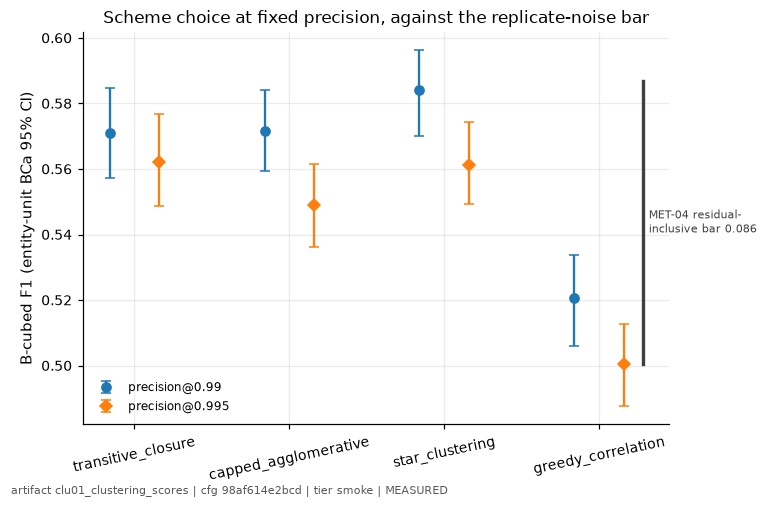

In [23]:
def draw_scheme_ledger(ax, df, meta):
    d = df[(df["row_type"] == "op") & df["protocol"].str.startswith("precision")]
    protos = sorted(d["protocol"].unique())
    offs = dict(zip(protos, (-0.16, 0.16)))
    marks = dict(zip(protos, ("o", "D")))
    xs = {s: i for i, s in enumerate(SCHEMES)}
    for proto in protos:
        g = d[d["protocol"] == proto]
        x = g["scheme"].map(xs).to_numpy(dtype=float) + offs[proto]
        yerr = np.vstack([np.clip(g["f1"] - g["f1_lo"], 0, None),
                          np.clip(g["f1_hi"] - g["f1"], 0, None)])
        ax.errorbar(x, g["f1"], yerr=yerr, fmt=marks[proto], capsize=3, markersize=6,
                    label=proto)
        for xi, (_, r) in zip(x, g.iterrows()):
            if r["fallback"]:
                ax.annotate("fallback", (xi, r["f1"]), textcoords="offset points",
                            xytext=(0, -14), ha="center", fontsize=6.5, color="C3")
    y0 = float(d["f1"].min())
    ax.plot([len(SCHEMES) - 0.72] * 2, [y0, y0 + BAR_FULL], color="0.25", linewidth=2.2)
    ax.annotate(f"MET-04 residual-\ninclusive bar {BAR_FULL:.3f}",
                (len(SCHEMES) - 0.68, y0 + BAR_FULL / 2), fontsize=7.5, color="0.25",
                va="center")
    ax.set_xticks(range(len(SCHEMES)), SCHEMES, rotation=12)
    ax.set_ylabel("B-cubed F1 (entity-unit BCa 95% CI)")
    ax.legend(loc="lower left", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="clu01_clustering_scores",
    draw=draw_scheme_ledger,
    title="Scheme choice at fixed precision, against the replicate-noise bar",
    figsize=(7.0, 4.6),
)

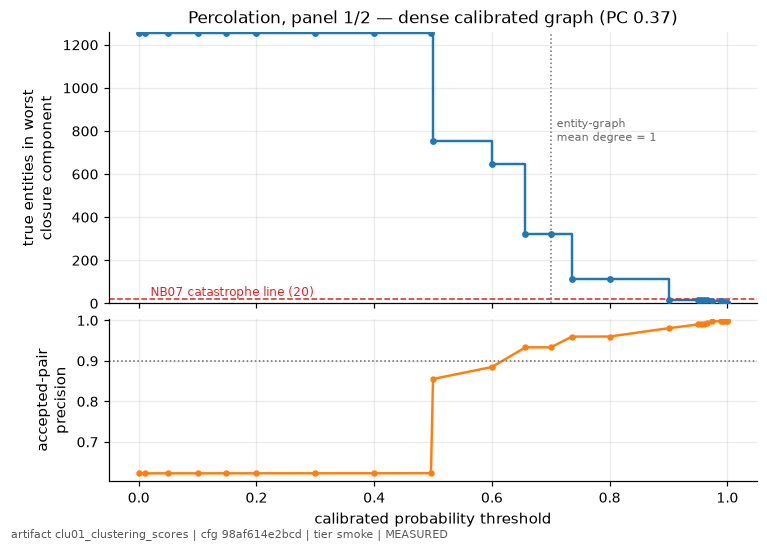

In [24]:
# Shared axis limits for the two aligned percolation panels (set from THIS run's sweep).
PERC_YMAX = max(MAX_FUSED_SWEEP, FUSE_CATASTROPHE) + 4
PERC_PMIN = min(float(sweep["edge_precision"].min()),
                float(CM_SWEEP["edge_precision"].min()), PW_FLOOR) - 0.02


def _collapse_panels(ax, sw, onset_t, xlabel="calibrated probability threshold"):
    sw = sw.sort_values("threshold")
    ax.plot(sw["threshold"], sw["max_entities_fused"], color="C0", drawstyle="steps-post",
            linewidth=1.6)
    ax.scatter(sw["threshold"], sw["max_entities_fused"], s=12, color="C0", zorder=3)
    ax.axhline(FUSE_CATASTROPHE, linestyle="--", color="C3", linewidth=1.0)
    ax.text(0.02, FUSE_CATASTROPHE + 0.6, f"NB07 catastrophe line ({FUSE_CATASTROPHE})",
            color="C3", fontsize=8, va="bottom")
    if np.isfinite(onset_t):
        ax.axvline(onset_t, linestyle=":", color="0.45", linewidth=1.0)
        ax.text(onset_t + 0.01, PERC_YMAX * 0.6, "entity-graph\nmean degree = 1",
                color="0.4", fontsize=7)
    ax.set_ylim(0, PERC_YMAX)
    ax.set_ylabel("true entities in worst\nclosure component")
    ax.tick_params(axis="x", labelbottom=False)
    axp = make_axes_locatable(ax).append_axes("bottom", size="60%", pad=0.14, sharex=ax)
    axp.plot(sw["threshold"], sw["edge_precision"], color="C1", linewidth=1.6)
    axp.scatter(sw["threshold"], sw["edge_precision"], s=10, color="C1", zorder=3)
    axp.axhline(PW_FLOOR, linestyle=":", color="0.4", linewidth=1.0)
    axp.set_ylim(PERC_PMIN, 1.004)
    axp.set_ylabel("accepted-pair\nprecision")
    axp.set_xlabel(xlabel)


def draw_perc_dense(ax, df, meta):
    _collapse_panels(ax, df[df["row_type"] == "sweep"], ONSET_T)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="clu01_clustering_scores", draw=draw_perc_dense,
    title=f"Percolation, panel 1/2 — dense calibrated graph (PC {PC_EV:.2f})",
    figsize=(7.0, 5.0),
)

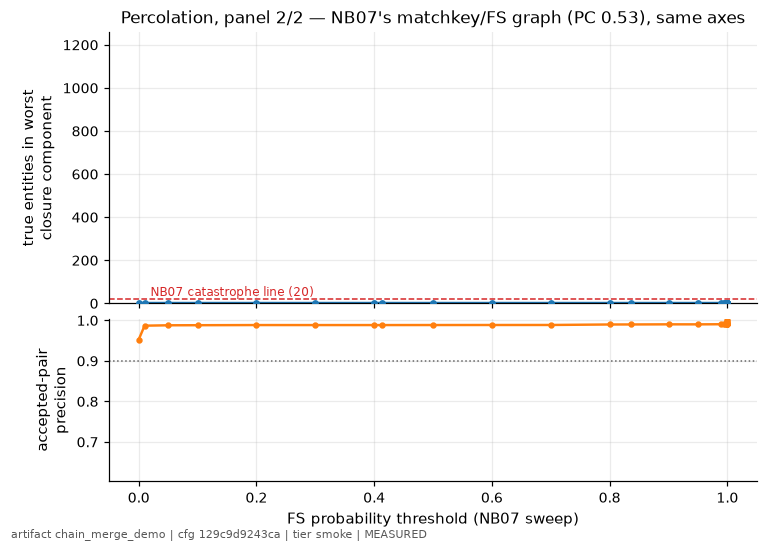

In [25]:
def draw_perc_fs(ax, df, meta):
    _collapse_panels(ax, df[df["row_type"] == "sweep"], np.nan,
                     xlabel="FS probability threshold (NB07 sweep)")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="chain_merge_demo", draw=draw_perc_fs,
    title=f"Percolation, panel 2/2 — NB07's matchkey/FS graph (PC {CM_PC:.2f}), "
          "same axes",
    figsize=(7.0, 5.0),
)

## 11. Pricing the real thing: CLU-01 at 1e7

In [26]:
# [RUN-IN-TARGET node] the definitive CLU-01 run: THESE same cells at tier=target on the
# node — 1e7-record calibrated corpus, multi-seed encoders per met04_power_table at that
# tier, same schemes, same operating-point protocol, same registry names. Hub resistance is
# only adjudicable there: at 1e7 the hub/common-name neighborhoods are ~300x denser, and
# star/capped guards face real sprawl. The estimates below use THIS run's measured
# coefficients (4-CPU container, single-thread faiss; a concurrent workload can inflate
# them 2-4x — planning numbers, re-measured on arrival).
if TIER == "target":
    print("tier=target: the operating points and sweep above ARE the definitive CLU-01 "
          "numbers at this scale; replicate counts come from met04_power_table at this "
          "tier.")
else:
    N7 = 1e7
    _clus_keys = [k for k in PRED_SECS if k[0] == "transitive_closure"]
    _clus_s_per_pair = np.median(
        [PRED_SECS[k] / max(int((prob_ev >= k[1]).sum()), 1) for k in _clus_keys])
    _pairs7 = N7 * (len(ev_scored) / N_EV)  # measured realized pairs/record at k=K_CAND
    _bas02_hnsw = bas02[(bas02["method"] == "ann_hnsw") & (bas02["k"] == K_CAND)].iloc[0]
    _hnsw_c = float(_bas02_hnsw["block_secs"]) / (N_ARENA * np.log2(N_ARENA))
    _hnsw_h = _hnsw_c * N7 * np.log2(N7) / 3600
    _enc_h = N7 / float(bas02_meta["extra"]["encode"]["records_per_sec"]) / 3600
    _t0 = time.time()
    _ = cal_iso_g.transform(ev_scored["cos"].to_numpy())  # transform cost, measured live
    _iso_s = time.time() - _t0
    print(f"[RUN-IN-TARGET node] CLU-01 at 1e7, priced from THIS run's coefficients "
          f"(n_eval={N_EV:,}, k={K_CAND}):")
    print(f"  candidates: ann_hnsw {float(_bas02_hnsw['block_secs']) / N_ARENA * 1e3:.2f} "
          f"ms/rec measured by BAS-02 -> ~{_hnsw_h:.1f} h at 1e7 under ~n·log2(n), single "
          "faiss thread (90 cores + 4 A100s to shard); encode "
          f"~{_enc_h:.1f} h at this container's rate, ~{N7 / 20_000 / 60:.0f} min on one "
          "A100 (PLAN §8 planning number)")
    print(f"  calibration: isotonic transform measured {_iso_s / len(prob_ev) * 1e9:.0f} "
          f"ns/pair -> ~{_iso_s / len(prob_ev) * _pairs7:.0f}s for "
          f"{_pairs7:.0e} pairs — calibration is never the bottleneck")
    print(f"  clustering: closure measured ~{_clus_s_per_pair * 1e6:.1f} µs/kept-pair "
          f"(python union-find) -> ~{_clus_s_per_pair * _pairs7 / 60:.0f} min if all "
          f"{_pairs7:.0e} pairs are kept; the operating points keep far fewer, and a "
          "numpy/scipy union-find is the obvious target-tier engineering (package note)")
    print(f"  memory: 1e7 x {EMB.shape[1]}-d fp32 embeddings = "
          f"{N7 * EMB.shape[1] * 4 / 2**30:.1f} GB; k={K_CAND} pair table "
          f"~{_pairs7:.0e} rows ~{_pairs7 * 50 / 2**30:.0f} GB as strings — inside the "
          "node's 900 GB (PLAN §8), but ids should be int-coded there")
    print(f"  the sweep's {len(sweep)} closure clusterings and {len(ops)} operating points "
          f"took {sum(PRED_SECS.values()):.0f}s of clustering here — the target run's "
          "cost is dominated by candidates + encode, not by the schemes themselves")

[RUN-IN-TARGET node] CLU-01 at 1e7, priced from THIS run's coefficients (n_eval=16,095, k=10):
  candidates: ann_hnsw 0.12 ms/rec measured by BAS-02 -> ~0.5 h at 1e7 under ~n·log2(n), single faiss thread (90 cores + 4 A100s to shard); encode ~2.1 h at this container's rate, ~8 min on one A100 (PLAN §8 planning number)
  calibration: isotonic transform measured 23 ns/pair -> ~2s for 7e+07 pairs — calibration is never the bottleneck
  clustering: closure measured ~1.5 µs/kept-pair (python union-find) -> ~2 min if all 7e+07 pairs are kept; the operating points keep far fewer, and a numpy/scipy union-find is the obvious target-tier engineering (package note)
  memory: 1e7 x 128-d fp32 embeddings = 4.8 GB; k=10 pair table ~7e+07 rows ~3 GB as strings — inside the node's 900 GB (PLAN §8), but ids should be int-coded there
  the sweep's 27 closure clusterings and 20 operating points took 24s of clustering here — the target run's cost is dominated by candidates + encode, not by the schemes the

### Verdict — scoring the CLU-01 card against the registered numbers

In [27]:
_po = ops[ops["row_type"] == "op"].set_index(["scheme", "protocol"])
spreads: dict[float, float] = {}
clean: dict[float, bool] = {}
for target in PREC_TARGETS:
    proto = f"precision@{target}"
    f1s = _po.xs(proto, level="protocol")["f1"]
    spreads[target] = float(f1s.max() - f1s.min())
    clean[target] = bool(
        (_po.xs(proto, level="protocol")["attained"] == 1.0).all())
_prec_deltas = deltas[deltas["protocol"].str.startswith("precision")]
refute_rows = _prec_deltas[_prec_deltas["exceeds_bar"] & _prec_deltas["sign_stable"]]
p1 = bool(spreads[PREC_TARGETS[0]] < BAR_FULL and clean[PREC_TARGETS[0]])
p2 = bool(spreads[PREC_TARGETS[1]] < BAR_FULL and clean[PREC_TARGETS[1]])
_op_fused_ok = bool(
    (ops[ops["protocol"].str.startswith("precision")]["max_entities_fused"]
     < FUSE_CATASTROPHE).all())
p3 = bool(MAX_FUSED_SWEEP > CM_MAX_FUSED and np.isfinite(ONSET_T) and _op_fused_ok)

for target in PREC_TARGETS:
    print(f"precision@{target}: scheme F1 spread {spreads[target]:.4f} vs bar "
          f"{BAR_FULL:.4f} ({'<' if spreads[target] < BAR_FULL else '>='} bar); "
          f"all schemes attained the target: {clean[target]}")
print(f"REFUTED clause: {len(refute_rows)} scheme pair(s) with |ΔF1| >= bar AND a "
      f"sign-stable CI"
      + ("" if refute_rows.empty else " -> " + ", ".join(
          f"{r['scheme']}-{r['scheme_b']}@{r['protocol']} {r['delta_f1']:+.4f}"
          for _, r in refute_rows.iterrows())))
print(f"P3 (subordinate): sweep max fusion {MAX_FUSED_SWEEP} vs NB07's {CM_MAX_FUSED}; "
      f"onset at t~{ONSET_T:.4f} ({'finite' if np.isfinite(ONSET_T) else 'none'}); all "
      f"precision-point fusions < {FUSE_CATASTROPHE}: {_op_fused_ok} -> {p3}")
if len(refute_rows):
    clu01_outcome = "REFUTED"
elif p1 and p2:
    clu01_outcome = "CONFIRMED"
else:
    clu01_outcome = "UNEXPLAINED"
print(f"-> outcome: {clu01_outcome}")

_ = verdict_box(
    "CLU-01",
    outcome=clu01_outcome,
    evidence=(
        f"clu01_clustering_scores (tier {TIER}; {SCHEME} eval half, {N_EV:,} records / "
        f"{N_ENT_EV:,} entities; ann_flat k={K_CAND} candidates, PC {PC_EV:.4f} vs NB07's "
        f"{CM_PC:.4f}; CAL-01 global-isotonic probabilities). P1: precision@"
        f"{PREC_TARGETS[0]} scheme-F1 spread {spreads[PREC_TARGETS[0]]:.4f} vs the "
        f"residual-inclusive bar {BAR_FULL:.4f} ({BAR_SRC}), all-attained="
        f"{clean[PREC_TARGETS[0]]} -> {p1}. P2: precision@{PREC_TARGETS[1]} spread "
        f"{spreads[PREC_TARGETS[1]]:.4f}, all-attained={clean[PREC_TARGETS[1]]} -> {p2}. "
        f"REFUTED clause: {len(refute_rows)} paired delta(s) both >= the bar and "
        f"sign-stable across {N_BOOT} shared entity resamples. P3 (subordinate) {p3}: the "
        f"dense graph percolates where NB07's refused — worst sweep fusion "
        f"{MAX_FUSED_SWEEP} true entities vs NB07's {CM_MAX_FUSED}, onset near the "
        f"entity-graph mean-degree=1 heuristic at t~{ONSET_T:.4f} — while every "
        f"fixed-precision operating point stays below the {FUSE_CATASTROPHE}-entity "
        "catastrophe line: the guards' insurance now demonstrably has something to insure "
        "against, and the protocol threshold is what keeps closure out of the fire. "
        "DEMONSTRATION, not adjudication: one trained encoder (seed "
        f"{PRIMARY_SEED}), one corpus draw, single-split eval — margins of bar size are "
        "run-to-run noise by MET-04's own measurement; hub resistance at 1e7 on the node "
        "(placard above) is the definitive CLU-01 run."
    ),
    registry=registry,
)

precision@0.99: scheme F1 spread 0.0637 vs bar 0.0865 (< bar); all schemes attained the target: True
precision@0.995: scheme F1 spread 0.0618 vs bar 0.0865 (< bar); all schemes attained the target: True
REFUTED clause: 0 scheme pair(s) with |ΔF1| >= bar AND a sign-stable CI
P3 (subordinate): sweep max fusion 1254 vs NB07's 4; onset at t~0.7000 (finite); all precision-point fusions < 20: True -> True
-> outcome: CONFIRMED


> ### VERDICT: CONFIRMED — card `CLU-01`
>
> **Conjecture** At fixed-precision operating points, the clustering scheme is a second-order choice on this corpus: with calibrated dense-candidate scores, transitive closure, capped agglomerative, star clustering, and greedy correlation land within replicate noise of each other on entity-level F — even though the dense candidate graph, unlike NB07's starved matchkey/FS graph, genuinely percolates at low thresholds (where the guards' insurance finally has something to pay out on).
>
> **Prediction** P1: at the precision@0.99 operating point (each scheme at its own loosest threshold attaining B-cubed precision 0.99), the max-minus-min B-cubed F1 across the four schemes is smaller than the MET-04 residual-inclusive single-seed bar read from met04_power_table meta at this tier. P2: the same at precision@0.995. P3 (subordinate, cannot flip the outcome): the dense candidate graph percolates where NB07's did not — the sweep's worst-component true-entity count exceeds chain_merge_demo's sweep maximum, with onset near the entity-graph mean-degree=1 heuristic — while at the precision operating points themselves every scheme stays below chain_merge_demo's catastrophe line (>= 20 entities fused). Decision rule, pre-registered: REFUTED iff at either fixed-precision point some scheme pair's B-cubed F1 delta has |delta| >= the bar AND its paired entity-BCa 95% CI excludes zero; CONFIRMED iff P1 and P2 both hold with every scheme actually attaining the target (an operating point where any scheme falls back to highest-attainable precision cannot CONFIRM — it can only REFUTE or leave UNEXPLAINED); UNEXPLAINED otherwise. Cost-grid points are reported, not scored. Single seed, one corpus draw, ~1.6e4-record eval half: a demonstration — hub resistance and this card's adjudication are the tier=target run at 1e7 (placard below).
>
> **Evidence** clu01_clustering_scores (tier smoke; entity_disjoint eval half, 16,095 records / 1,255 entities; ann_flat k=10 candidates, PC 0.3716 vs NB07's 0.5343; CAL-01 global-isotonic probabilities). P1: precision@0.99 scheme-F1 spread 0.0637 vs the residual-inclusive bar 0.0865 (read from met04_power_table meta), all-attained=True -> True. P2: precision@0.995 spread 0.0618, all-attained=True -> True. REFUTED clause: 0 paired delta(s) both >= the bar and sign-stable across 500 shared entity resamples. P3 (subordinate) True: the dense graph percolates where NB07's refused — worst sweep fusion 1254 true entities vs NB07's 4, onset near the entity-graph mean-degree=1 heuristic at t~0.7000 — while every fixed-precision operating point stays below the 20-entity catastrophe line: the guards' insurance now demonstrably has something to insure against, and the protocol threshold is what keeps closure out of the fire. DEMONSTRATION, not adjudication: one trained encoder (seed 17), one corpus draw, single-split eval — margins of bar size are run-to-run noise by MET-04's own measurement; hub resistance at 1e7 on the node (placard above) is the definitive CLU-01 run.


## 12. What the rest of the series inherits

- **Notebook 14 (HYB-01) consumes both artifacts by DAG contract.** Its hybrid
  arbitration — which deterministic rules earn a place as override/guard/feature — starts
  from `cal01_calibration_map`'s calibrated probabilities and per-stratum thresholds: a
  rule like "require an extra field agreement between common family names" is exactly the
  common-name discount this notebook priced (threshold rows), now with a probability scale
  on which rule and score can be traded against each other. The scheme ledger in
  `clu01_clustering_scores` tells NB14 which clustering to arbitrate behind (and how much
  that choice can matter).
- **Calibration transfer is the open finding CAL-01 hands forward.** The verdict cell's
  diagnostic separates fit capacity from transfer: the isotonic map is near-perfect on the
  entities it was fitted on and degrades on unseen ones, so notebook 16's per-group error
  measurement (which consumes `cal01_calibration_map` by DAG contract) inherits a
  calibrator whose residual error is itself entity-structured — exactly the kind of
  heterogeneity FAIR-01 exists to measure rather than assume away.
- **Notebook 15 (SCL) inherits the percolation instruments.** The sweep rows carry the
  entity-graph mean-degree onset alongside fusion counts; how that onset moves with corpus
  size is precisely the scale question, and the placard's measured coefficients seed its
  cost model.
- **The NB07 arc closes.** The guards were insurance premiums with no payout on the
  starved FS graph; on the dense calibrated graph the fire is real at low thresholds
  (sweep rows), and the protocol operating points — not the scheme — are what keep the
  partition out of it. Both halves of that sentence are now registered measurements.

**Package gaps noted this notebook** (worked around in-notebook, per the series
convention): no reliability/ECE helper in `er_lab.score.calibrate`; no shared home for
`entity_complete_subsample` (05/09/12/13 each carry a copy); `reporting.figures` has no
multi-artifact provenance stamping (two aligned panels instead); a numpy union-find for
target-tier closure.

**Artifacts registered** (exact names): `cal01_calibration_map`,
`clu01_clustering_scores` — plus the immutable cards `card_CAL-01` and `card_CLU-01`.

In [28]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 min "
      "uncontended"
      + ("" if total <= 2100 else "  <-- over that budget at this run (see section table; "
                                  "a concurrent notebook re-execution contends for these "
                                  "4 CPUs)"))

,section,secs
0,§1 arena + recipe + bars,0.0
1,§3a recipe retrain,36.0
2,§3b encode,19.0
3,§4 fit pairs + strata,21.0
4,§5 calibration fits + register,2.0
5,§7 candidate graph + calibrate,3.0
6,§8 operating points + CIs,36.0
7,§9 percolation sweep + paired deltas,4.0
8,§9b register,0.0


notebook wall-clock: 123s (2.0 min) — smoke budget <= ~30 min uncontended
